# 05 Topic Modeling with BERTopic

## Objective

The purpose of this notebook is to identify latent themes within open-ended survey comments using BERTopic.

While sentiment analysis focuses on how respondents express their opinions, topic modelling focuses on what respondents are talking about.

The resulting topics provide an additional analytical layer that complements the emotional dimensions generated in previous notebooks.

The analysis aims to:

- identify recurring discussion themes,
- group semantically similar comments,
- generate interpretable topic labels,
- explore topic prevalence,
- and create dashboard-ready topic features.

The resulting topic assignments will later be combined with sentiment and affective measures to build the ELFI (Emotional & Latent Feedback Interpretation) dashboard.

## Dataset

The analysis is performed on real High5 survey comments.

Dataset characteristics:

- Total survey records: 46,781
- Comments available: 4,328
- Unique comments: 4,271

Compared to the synthetic development dataset, the real comments contain a substantially larger thematic variety. This is expected to improve topic quality and interpretability.

## Why BERTopic?

BERTopic combines transformer-based semantic embeddings with clustering techniques to identify meaningful topics in unstructured text.

Compared to traditional topic modelling approaches such as LDA, BERTopic generally produces more coherent and interpretable topics for short text segments.

The model is particularly suitable for survey comments because it captures contextual similarity rather than relying solely on word frequencies.

## Expected Output

For each comment the model will generate:

- Topic ID
- Topic Label
- Topic Probability

These outputs will later be merged with sentiment and survey features for downstream analyses and dashboard visualisation.

In [65]:
# ============================================================
# Imports
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path

from sentence_transformers import SentenceTransformer

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer

print("All imports successful.")

All imports successful.


## Load Data

The analysis is performed on the cleaned synthetic dataset produced during the exploratory data analysis stage.

Only comments containing textual feedback are retained for topic modelling.


In [66]:
# ============================================================
# Load Data
# ============================================================

DATA_PATH = Path(
    "../data/processed/synthetic_eda_ready.csv"
)

data = pd.read_csv(
    DATA_PATH,
    low_memory=False
    )

In [67]:
# ============================================================
# Dataset Overview
# ============================================================

COMMENT_COL = "freitext_kommentar"

print(f"Rows: {len(data):,}")
print(f"Columns: {len(data.columns):,}")

print("\nComment statistics:")

print(
    f"Non-null comments: "
    f"{data[COMMENT_COL].notna().sum():,}"
)

print(
    f"Unique comments: "
    f"{data[COMMENT_COL].nunique():,}"
)

print(
    f"Missing comments: "
    f"{data[COMMENT_COL].isna().sum():,}"
)

Rows: 7,000
Columns: 79

Comment statistics:
Non-null comments: 5,000
Unique comments: 4,955
Missing comments: 2,000


## Dataset Overview

The real High5 dataset contains 46,781 survey records.

Only a subset of respondents provided free-text feedback. Therefore, an initial quality check was conducted to determine the number of available comments, missing values, and unique responses before topic modelling.

These comments form the basis for the BERTopic analysis.

## Comment Preparation

Missing values and empty responses were removed prior to topic modelling.

A total of 4,328 comments remained for analysis.

The comments were converted to string format and stripped of leading and trailing whitespace to ensure consistent processing.

The resulting text corpus forms the input for BERTopic.

In [68]:
# ============================================================
# Prepare Comments
# ============================================================

comments = (
    data["freitext_kommentar"]
    .dropna()
    .astype(str)
    .str.strip()
)

comments = comments[
    comments != ""
]

print(f"Comments available: {len(comments):,}")
print(f"Unique comments: {comments.nunique():,}")

comments.head()

Comments available: 5,000
Unique comments: 4,955


0    Im Kontext 'Wissensaustausch und Lernen' werde...
2    Im Kontext 'Kollaborativer Arbeitsmodus' werde...
4    Im Kontext 'Wissensaustausch und Lernen' werde...
5    Im Kontext 'Reflektion und Verbesserung' werde...
7    Im Kontext 'Kollaborativer Arbeitsmodus' werde...
Name: freitext_kommentar, dtype: object

## Load Embedding Model

BERTopic relies on semantic embeddings to identify similar comments.

The multilingual MiniLM model is used to transform each comment into a dense vector representation while preserving semantic meaning.

These embeddings form the foundation for subsequent clustering and topic extraction.
`

In [69]:
# ============================================================
# Load Embedding Model
# ============================================================

embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

print("Embedding model loaded successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding model loaded successfully.


## Initialise BERTopic

A baseline BERTopic model is created using the multilingual embedding model.

The purpose of this initial configuration is to establish a reference point before introducing further optimisation steps such as custom stopword handling, vectorizer tuning, improved topic representations, BM25 weighting, and clustering parameter adjustments.

This iterative approach allows the impact of each optimisation on topic quality, interpretability, and outlier reduction to be evaluated systematically.

The baseline model therefore serves as a benchmark against which all subsequent BERTopic configurations can be compared.

In [70]:
# ============================================================
# Initialise BERTopic
# ============================================================

topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

print("BERTopic initialised.")

BERTopic initialised.


## Fit BERTopic Model

BERTopic is trained on the survey comments to identify recurring discussion themes.

A minimum topic size is specified to avoid the generation of very small and difficult-to-interpret topics.

In [71]:
# ============================================================
# Fit BERTopic
# ============================================================

topic_model = BERTopic(
    embedding_model=embedding_model,
    language="multilingual",
    calculate_probabilities=True,
    min_topic_size=30,
    verbose=True
)

topics, probabilities = topic_model.fit_transform(
    comments.tolist()
)

print(
    f"Unique topics: {len(set(topics))}"
)

2026-08-05 15:00:30,707 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-08-05 15:00:47,201 - BERTopic - Embedding - Completed ✓
2026-08-05 15:00:47,202 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-05 15:00:48,349 - BERTopic - Dimensionality - Completed ✓
2026-08-05 15:00:48,350 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-05 15:00:48,552 - BERTopic - Cluster - Completed ✓
2026-08-05 15:00:48,557 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-05 15:00:48,661 - BERTopic - Representation - Completed ✓


Unique topics: 27


A larger minimum topic size was used than in the synthetic-data experiments. Due to the substantially larger number of available comments, larger topic clusters can be formed, resulting in more stable and interpretable topics.

In [72]:
# ============================================================
# Topic Overview
# ============================================================

topic_info = topic_model.get_topic_info()

display(topic_info)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,604,-1_und_die_babelfish_wissenstransfer,"[und, die, babelfish, wissenstransfer, verstän...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
1,0,996,0_werden_diskutiert_und_der,"[werden, diskutiert, und, der, wird, die, von,...",[Im Kontext 'Tägliches operatives Geschäft' we...
2,1,578,1_genannt_gedächtnis_agrajag_lernens,"[genannt, gedächtnis, agrajag, lernens, liga, ...",[Im Kontext 'Wissensaustausch und Lernen' werd...
3,2,519,2_datenbasierten_verbunden_deepthought_neuen,"[datenbasierten, verbunden, deepthought, neuen...",[Im Kontext 'Reflektion und Verbesserung' werd...
4,3,441,3_priorisierungsdiskussionen_beeinflusst_spürb...,"[priorisierungsdiskussionen, beeinflusst, spür...",[Im Kontext 'Kein spezifischer Fokus' werden i...
5,4,244,4_veränderungsphasen_initiative_bezeichnet_ori...,"[veränderungsphasen, initiative, bezeichnet, o...",[Im Kontext 'Tägliches operatives Geschäft' we...
6,5,241,5_digitalisierung_und_werden_arbeitsabläufe,"[digitalisierung, und, werden, arbeitsabläufe,...",[Im Kontext 'Kein spezifischer Fokus' werden i...
7,6,118,6_the_and_additional_employees,"[the, and, additional, employees, best, as, co...","[In the context of strategischer austausch, em..."
8,7,112,7_teams_zusammenarbeit_die_den,"[teams, zusammenarbeit, die, den, unterstützt,...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
9,8,89,8_arbeitgeberattraktivität_die_beeinflussen_des,"[arbeitgeberattraktivität, die, beeinflussen, ...",[Im Kontext 'Reflektion und Verbesserung' werd...


## Baseline Results

The baseline BERTopic configuration produced only two topics, with one dominant topic containing almost all comments.

The resulting topic representation was largely driven by common German function words and therefore lacked interpretability.

This result confirmed the need for additional preprocessing and topic-model optimisation steps, including custom stopword removal and vectorizer tuning.

# Count Vectorizer

Compared to the baseline model, an extended stopword list is applied.

The stopword list contains both common German stopwords and survey-specific filler expressions identified during exploratory analyses. In addition, a minimum document frequency of 2 is used to retain infrequent but potentially meaningful terms in the larger real-world dataset.

In [73]:
# ============================================================
# Count Vectorizer
# ============================================================

from sklearn.feature_extraction.text import CountVectorizer

# # Load extended stopword list
# STOPWORD_PATH = Path(
#     "../data/config/german_stopwords_extended.txt"
# )

# Load extended stopword list
STOPWORD_PATH = Path(
    "../data/config/german_stopwords_full.txt"
)

with open(
    STOPWORD_PATH,
    "r",
    encoding="utf-8"
) as f:
    german_stop_words = [
        line.strip()
        for line in f
        if line.strip()
    ]

print(
    f"Loaded {len(german_stop_words)} stopwords."
)

vectorizer_model = CountVectorizer(
    stop_words=german_stop_words,
    ngram_range=(1, 2),
    min_df=2
)

Loaded 1858 stopwords.


Compared to the baseline model, an extended stopword list is applied through the CountVectorizer.

To allow the discovery of more fine-grained themes in the substantially larger real-world dataset, the minimum topic size remains at 20 comments. Additional clustering optimisations will be introduced in subsequent model versions.

In [74]:
# ============================================================
# BERTopic
# ============================================================

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=True,
    min_topic_size=20,
    verbose=True
)

In [75]:
topics, probabilities = topic_model.fit_transform(
    comments.tolist()
)

2026-08-05 15:00:48,828 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-08-05 15:01:05,510 - BERTopic - Embedding - Completed ✓
2026-08-05 15:01:05,511 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-05 15:01:06,899 - BERTopic - Dimensionality - Completed ✓
2026-08-05 15:01:06,900 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-05 15:01:07,198 - BERTopic - Cluster - Completed ✓
2026-08-05 15:01:07,200 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-05 15:01:07,341 - BERTopic - Representation - Completed ✓


In [76]:
topic_info = topic_model.get_topic_info()

topic_info.head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,740,-1_teams_einschätzung_unterstützt_wissenstransfer,"[teams, einschätzung, unterstützt, wissenstran...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
1,0,994,0_diskutiert_sichtbar_zeigt_sichtbar kontext,"[diskutiert, sichtbar, zeigt, sichtbar kontext...",[Im Kontext 'Kein spezifischer Fokus' werden i...
2,1,525,1_liga_lernens_lernens genannt_liga kontext,"[liga, lernens, lernens genannt, liga kontext,...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
3,2,441,2_beeinflusst_beeinflusst arbeitsabläufe_prior...,"[beeinflusst, beeinflusst arbeitsabläufe, prio...",[Im Kontext 'Reflektion und Verbesserung' werd...
4,3,181,3_the_additional_effectiveness_improvement,"[the, additional, effectiveness, improvement, ...","[In the context of konzeptionelles arbeiten, e..."
5,4,144,4_digitalisierung diskutiert_themen digitalisi...,"[digitalisierung diskutiert, themen digitalisi...",[Im Kontext 'Tägliches operatives Geschäft' we...
6,5,101,5_datenbasierten entscheidungen_arbeitsweisen ...,"[datenbasierten entscheidungen, arbeitsweisen ...",[Im Kontext 'Kein spezifischer Fokus' werden i...
7,6,98,6_deepthought_datenbasierten entscheidungen_da...,"[deepthought, datenbasierten entscheidungen, d...",[Im Kontext 'Kreativ- und Ideenfindung' werden...
8,7,88,7_themen arbeitgeberattraktivität_arbeitgebera...,"[themen arbeitgeberattraktivität, arbeitgebera...",[Im Kontext 'Strategischer Austausch' werden i...
9,8,88,8_spürbar babelfish_priorisierungsdiskussionen...,"[spürbar babelfish, priorisierungsdiskussionen...",[Im Kontext 'Planung und Ausrichtung' werden i...


In [77]:
comments.sample(20, random_state=42).tolist()

["Im Kontext 'Strategischer Austausch' werden insbesondere Themen rund um Führung diskutiert. Transparente Entscheidungen werden als besonders wichtig angesehen. Die Initiative Keine_Panik wird häufig als Orientierungshilfe in Veränderungsphasen bezeichnet. Babelfish unterstützt nach Einschätzung vieler Teams den Wissenstransfer und die Verständigung. Projekt42 beeinflusst Arbeitsabläufe und Priorisierungsdiskussionen spürbar. Ein Teil der Rückmeldungen weist auf Enttäuschung und Reibungsverluste hin. Mehrere Mitarbeitende berichten weiterhin von Herausforderungen. Die Umsetzungsgeschwindigkeit sollte erhöht werden. Insgesamt zeigt sich innerhalb von ZU-BE (Zukunftssegment Beta) ein differenziertes Bild, bei dem Chancen und Herausforderungen gleichzeitig sichtbar werden.",
 "Im Kontext 'Tägliches operatives Geschäft' werden insbesondere Themen rund um Führung diskutiert. Transparente Entscheidungen werden als besonders wichtig angesehen. Langfristige Perspektiven spielen eine wichtige 

In [78]:
# Show Keywords with Weights

topic_model.get_topic(0)
topic_model.get_topic(1)
topic_model.get_topic(2)

[('beeinflusst', np.float64(0.03392574558396016)),
 ('beeinflusst arbeitsabläufe', np.float64(0.03392574558396016)),
 ('priorisierungsdiskussionen', np.float64(0.03392574558396016)),
 ('priorisierungsdiskussionen spürbar', np.float64(0.03392574558396016)),
 ('projekt42 beeinflusst', np.float64(0.03392574558396016)),
 ('projekt42', np.float64(0.03392574558396016)),
 ('spürbar', np.float64(0.03392574558396016)),
 ('arbeitsabläufe priorisierungsdiskussionen',
  np.float64(0.03392574558396016)),
 ('arbeitsabläufe', np.float64(0.02979163505795687)),
 ('sichtbar', np.float64(0.014350300417684191))]

In [79]:
topic_model.get_document_info(
    comments.tolist()
).head()

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,Im Kontext 'Wissensaustausch und Lernen' werde...,1,1_liga_lernens_lernens genannt_liga kontext,"[liga, lernens, lernens genannt, liga kontext,...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...,liga - lernens - lernens genannt - liga kontex...,0.296395,False
1,Im Kontext 'Kollaborativer Arbeitsmodus' werde...,41,41_kontext kollaborativer_arbeitsmodus themen_...,"[kontext kollaborativer, arbeitsmodus themen, ...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...,kontext kollaborativer - arbeitsmodus themen -...,1.000000,False
2,Im Kontext 'Wissensaustausch und Lernen' werde...,2,2_beeinflusst_beeinflusst arbeitsabläufe_prior...,"[beeinflusst, beeinflusst arbeitsabläufe, prio...",[Im Kontext 'Reflektion und Verbesserung' werd...,beeinflusst - beeinflusst arbeitsabläufe - pri...,1.000000,False
3,Im Kontext 'Reflektion und Verbesserung' werde...,0,0_diskutiert_sichtbar_zeigt_sichtbar kontext,"[diskutiert, sichtbar, zeigt, sichtbar kontext...",[Im Kontext 'Kein spezifischer Fokus' werden i...,diskutiert - sichtbar - zeigt - sichtbar konte...,0.668039,False
4,Im Kontext 'Kollaborativer Arbeitsmodus' werde...,-1,-1_teams_einschätzung_unterstützt_wissenstransfer,"[teams, einschätzung, unterstützt, wissenstran...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...,teams - einschätzung - unterstützt - wissenstr...,0.705222,False


In [80]:
# ============================================================
# Check artefact frequency
# ============================================================

artefact_mask = comments.str.contains(
    "ODTUTWAS|odtutwas|code",
    case=False,
    na=False
)

print(
    f"Comments containing artefacts: {artefact_mask.sum():,}"
)

comments[artefact_mask].head(20).tolist()

Comments containing artefacts: 0


[]

## Artefact Check

After applying the CountVectorizer, the topic representation was dominated by artefact-like tokens such as `ODTUTWASODTUT` and `code`.

Although the sampled comments showed meaningful survey feedback, a small number of recurring artefacts strongly influenced the topic names because most comments were assigned to one dominant cluster.

Therefore, an additional topic-specific cleaning step was introduced before refitting the model.

In [81]:
# ============================================================
# Clean Comments for Topic Modeling
# ============================================================

comments_clean = (
    comments
    .str.replace(
        r"#?ODTUTWASODSOTUT|#?ODTUTWASODTUT",
        "",
        regex=True,
        case=False
    )
    .str.replace(
        r"\bcode\b",
        "",
        regex=True,
        case=False
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

comments_clean = comments_clean[
    comments_clean != ""
]

print(
    f"Comments after topic-specific cleaning: {len(comments_clean):,}"
)

comments_clean.sample(
    10,
    random_state=42
).tolist()

Comments after topic-specific cleaning: 5,000


["Im Kontext 'Strategischer Austausch' werden insbesondere Themen rund um Führung diskutiert. Transparente Entscheidungen werden als besonders wichtig angesehen. Die Initiative Keine_Panik wird häufig als Orientierungshilfe in Veränderungsphasen bezeichnet. Babelfish unterstützt nach Einschätzung vieler Teams den Wissenstransfer und die Verständigung. Projekt42 beeinflusst Arbeitsabläufe und Priorisierungsdiskussionen spürbar. Ein Teil der Rückmeldungen weist auf Enttäuschung und Reibungsverluste hin. Mehrere Mitarbeitende berichten weiterhin von Herausforderungen. Die Umsetzungsgeschwindigkeit sollte erhöht werden. Insgesamt zeigt sich innerhalb von ZU-BE (Zukunftssegment Beta) ein differenziertes Bild, bei dem Chancen und Herausforderungen gleichzeitig sichtbar werden.",
 "Im Kontext 'Tägliches operatives Geschäft' werden insbesondere Themen rund um Führung diskutiert. Transparente Entscheidungen werden als besonders wichtig angesehen. Langfristige Perspektiven spielen eine wichtige 

In [82]:
# ============================================================
# Fit BERTopic with Cleaned Comments
# ============================================================

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=True,
    min_topic_size=20,
    verbose=True
)

topics, probabilities = topic_model.fit_transform(
    comments_clean.tolist()
)

topic_info = topic_model.get_topic_info()

display(
    topic_info.head(10)
)

2026-08-05 15:01:07,907 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-08-05 15:01:26,003 - BERTopic - Embedding - Completed ✓
2026-08-05 15:01:26,004 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-05 15:01:27,273 - BERTopic - Dimensionality - Completed ✓
2026-08-05 15:01:27,274 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-05 15:01:27,600 - BERTopic - Cluster - Completed ✓
2026-08-05 15:01:27,603 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-05 15:01:27,777 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,765,-1_teams_einschätzung_unterstützt_teams wissen...,"[teams, einschätzung, unterstützt, teams wisse...",[Im Kontext 'Kreativ- und Ideenfindung' werden...
1,0,996,0_diskutiert_sichtbar_zeigt_sichtbar kontext,"[diskutiert, sichtbar, zeigt, sichtbar kontext...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
2,1,440,1_priorisierungsdiskussionen_priorisierungsdis...,"[priorisierungsdiskussionen, priorisierungsdis...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
3,2,355,2_genannt_gedächtnis_gedächtnis liga_agrajag,"[genannt, gedächtnis, gedächtnis liga, agrajag...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
4,3,244,3_veränderungsphasen bezeichnet_orientierungsh...,"[veränderungsphasen bezeichnet, orientierungsh...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
5,4,149,4_digitalisierung diskutiert_themen digitalisi...,"[digitalisierung diskutiert, themen digitalisi...",[Im Kontext 'Strategischer Austausch' werden i...
6,5,103,5_arbeitsweisen_datenbasierten entscheidungen_...,"[arbeitsweisen, datenbasierten entscheidungen,...",[Im Kontext 'Tägliches operatives Geschäft' we...
7,6,100,6_strategie_strategie diskutiert_themen strate...,"[strategie, strategie diskutiert, themen strat...",[Im Kontext 'Tägliches operatives Geschäft' we...
8,7,88,7_verbunden babelfish_deepthought_arbeitsweise...,"[verbunden babelfish, deepthought, arbeitsweis...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
9,8,88,8_spürbar babelfish_priorisierungsdiskussionen...,"[spürbar babelfish, priorisierungsdiskussionen...",[Im Kontext 'Planung und Ausrichtung' werden i...


In [83]:
# ============================================================
# Show Keywords with Weights
# ============================================================

for topic_id in topic_info["Topic"].head(10):
    print(f"\nTopic {topic_id}")
    print(topic_model.get_topic(topic_id))


Topic -1
[('teams', np.float64(0.015486996199358631)), ('einschätzung', np.float64(0.015282517016043561)), ('unterstützt', np.float64(0.015109872412788699)), ('teams wissenstransfer', np.float64(0.014965466219483472)), ('unterstützt einschätzung', np.float64(0.014965466219483472)), ('verständigung', np.float64(0.014965466219483472)), ('babelfish', np.float64(0.014965466219483472)), ('einschätzung teams', np.float64(0.014965466219483472)), ('babelfish unterstützt', np.float64(0.014965466219483472)), ('wissenstransfer verständigung', np.float64(0.014965466219483472))]

Topic 0
[('diskutiert', np.float64(0.019219495361398806)), ('sichtbar', np.float64(0.015517482219626955)), ('zeigt', np.float64(0.015266712962233328)), ('sichtbar kontext', np.float64(0.015033019418117742)), ('differenziertes bild', np.float64(0.014880389131043765)), ('differenziertes', np.float64(0.014880389131043765)), ('themen', np.float64(0.014880389131043765)), ('herausforderungen sichtbar', np.float64(0.014880389131

## CountVectorizer Results

The introduction of the CountVectorizer with an extended stopword list substantially improved topic interpretability.

Several meaningful discussion themes emerged, including:

| Topic | Interpretation |
|---------|---------|
| 0 | Entscheidungen, Priorisierung und organisatorischer Fokus |
| 1 | Campus, Anwesenheit und 50%-Regel |
| 3 | Händlergeschäft, Plattformstrategie und Marktplatz |
| 4 | Positives Teamfeedback und Wertschätzung |
| 5 | Teamstimmung und Zusammenarbeit |
| 6 | High5, Umfragen und Ergebnisnutzung |
| 7 | Führungskräfte und Führung |

These themes align well with known discussion areas within the High5 survey and indicate that BERTopic is beginning to identify meaningful organisational topics rather than merely grouping comments by linguistic patterns.

The identified topics are particularly encouraging because they reflect distinct organisational themes that are also visible during manual review of the comments. Topics relating to leadership, collaboration, campus attendance, strategic direction, and employee feedback processes suggest that the semantic embeddings capture meaningful aspects of employees' experiences and concerns.

At the same time, more than half of all comments were still assigned to the outlier topic (-1). This suggests that the default clustering configuration was not yet able to group many semantically related comments into stable clusters.

Further optimisation therefore focuses on reducing the outlier rate while maintaining or improving topic interpretability.

## KeyBERT-Inspired Topic Representation

While the CountVectorizer improved topic quality, some topic descriptions still included highly frequent but only weakly informative terms.

To generate more interpretable topic representations, BERTopic's KeyBERTInspired representation model is applied. This approach selects keywords that are semantically more representative of a topic, resulting in clearer and more meaningful topic descriptions.

In [84]:
# ============================================================
# KeyBERTInspired Representation
# ============================================================

from bertopic.representation import KeyBERTInspired

representation_model = KeyBERTInspired()

In [85]:
# ============================================================
# BERTopic with KeyBERTInspired
# ============================================================

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    language="multilingual",
    calculate_probabilities=True,
    min_topic_size=20,
    verbose=True
)

print("BERTopic initialised.")

BERTopic initialised.


In [86]:
# ============================================================
# Fit BERTopic
# ============================================================

topics, probabilities = topic_model.fit_transform(
    comments_clean.tolist()
)

print(
    f"Unique topics: {len(set(topics))}"
)

2026-08-05 15:01:28,002 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-08-05 15:01:46,561 - BERTopic - Embedding - Completed ✓
2026-08-05 15:01:46,561 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-05 15:01:47,827 - BERTopic - Dimensionality - Completed ✓
2026-08-05 15:01:47,827 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-05 15:01:48,120 - BERTopic - Cluster - Completed ✓
2026-08-05 15:01:48,121 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-05 15:01:48,979 - BERTopic - Representation - Completed ✓


Unique topics: 42


In [87]:
# ============================================================
# Topic Overview
# ============================================================

topic_info = topic_model.get_topic_info()

display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,718,-1_organisationalen lernens_kontext organisati...,"[organisationalen lernens, kontext organisatio...",[Im Kontext 'Kreativ- und Ideenfindung' werden...
1,0,996,0_veränderungsmüdigkeit diskutiert_diskutiert ...,"[veränderungsmüdigkeit diskutiert, diskutiert ...",[Im Kontext 'Kein spezifischer Fokus' werden i...
2,1,519,1_strategie diskutiert_anpassung sinnvoll_führ...,"[strategie diskutiert, anpassung sinnvoll, füh...",[Im Kontext 'Wissensaustausch und Lernen' werd...
3,2,441,2_arbeitsabläufe priorisierungsdiskussionen_zu...,"[arbeitsabläufe priorisierungsdiskussionen, zu...",[Im Kontext 'Wissensaustausch und Lernen' werd...
4,3,244,3_unterschiedlich initiative_zusammenarbeit di...,"[unterschiedlich initiative, zusammenarbeit di...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
5,4,201,4_team arbeitskontext_kontext organisationalen...,"[team arbeitskontext, kontext organisationalen...",[Im Kontext 'Wissensaustausch und Lernen' werd...
6,5,152,5_verändern arbeitsabläufe_veränderungsmüdigke...,"[verändern arbeitsabläufe, veränderungsmüdigke...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
7,6,88,6_strategie diskutiert_arbeitsweisen verbunden...,"[strategie diskutiert, arbeitsweisen verbunden...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
8,7,88,7_arbeitsabläufe priorisierungsdiskussionen_pr...,"[arbeitsabläufe priorisierungsdiskussionen, pr...",[Im Kontext 'Planung und Ausrichtung' werden i...
9,8,84,8_wissenstransfer verständigung_diskutiert ent...,"[wissenstransfer verständigung, diskutiert ent...",[Im Kontext 'Strategischer Austausch' werden i...


## KeyBERTInspired Results

Applying the KeyBERTInspired representation model improved the semantic quality of the topic descriptions.

Several clearly interpretable organisational themes emerged, including:

| Topic | Interpretation |
|---------|---------|
| 3 | Strategie und Management |
| 4 | Arbeit, Team und Zusammenarbeit |
| 5 | Zusammenarbeit und Teamklima |
| 6 | High5, Feedback und Befragungen |
| 7 | Wertschätzung und Anerkennung |
| 8 | Führungskräfte und Verantwortlichkeiten |
| 1 | Arbeiten am Campus und Arbeitsbedingungen |

These topics closely align with themes that are also identifiable through manual review of the comments, indicating that the embedding model captures meaningful organisational content.

Compared to the CountVectorizer-only configuration, KeyBERTInspired produced more descriptive and semantically meaningful topic labels. However, the overall clustering structure and outlier rate changed only marginally.

This suggests that topic representation has improved, while further optimisation should focus on topic separation and cluster formation.

## Improving Topic Quality with BM25 Weighting

BM25 weighting is applied to the class-based TF-IDF representation used by BERTopic.

Compared to standard c-TF-IDF, BM25 places greater emphasis on terms that are particularly characteristic of a topic while reducing the influence of very common terms.

The objective of this step is not to improve clustering performance, but to generate clearer and more informative topic representations that are easier to interpret.

In [88]:
# ============================================================
# BM25 c-TF-IDF
# ============================================================

from bertopic.vectorizers import ClassTfidfTransformer

ctfidf_model = ClassTfidfTransformer(
    bm25_weighting=True
)

In [89]:
# ============================================================
# BERTopic with KeyBERTInspired + BM25
# ============================================================

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    ctfidf_model=ctfidf_model,
    language="multilingual",
    calculate_probabilities=True,
    min_topic_size=20,
    verbose=True
)

print("BERTopic initialised.")


BERTopic initialised.


In [90]:
# ============================================================
# Fit BERTopic
# ============================================================

topics, probabilities = topic_model.fit_transform(
    comments_clean.tolist()
)

print(
    f"Unique topics: {len(set(topics))}"
)

2026-08-05 15:01:49,238 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-08-05 15:02:07,237 - BERTopic - Embedding - Completed ✓
2026-08-05 15:02:07,238 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-05 15:02:08,568 - BERTopic - Dimensionality - Completed ✓
2026-08-05 15:02:08,569 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-05 15:02:08,846 - BERTopic - Cluster - Completed ✓
2026-08-05 15:02:08,848 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-05 15:02:09,521 - BERTopic - Representation - Completed ✓


Unique topics: 38


In [91]:
# ============================================================
# Topic Overview
# ============================================================

topic_info = topic_model.get_topic_info()

display(
    topic_info.head(10)
)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,632,-1_wissenstransfer verständigung_verständigung...,"[wissenstransfer verständigung, verständigung ...",[Im Kontext 'Planung und Ausrichtung' werden i...
1,0,995,0_veränderungsmüdigkeit diskutiert_diskutiert ...,"[veränderungsmüdigkeit diskutiert, diskutiert ...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
2,1,519,1_strategie diskutiert_anpassung sinnvoll_zuve...,"[strategie diskutiert, anpassung sinnvoll, zuv...",[Im Kontext 'Wissensaustausch und Lernen' werd...
3,2,441,2_arbeitsabläufe priorisierungsdiskussionen_zu...,"[arbeitsabläufe priorisierungsdiskussionen, zu...",[Im Kontext 'Wissensaustausch und Lernen' werd...
4,3,347,3_kontext organisationalen_organisationalen le...,"[kontext organisationalen, organisationalen le...",[Im Kontext 'Tägliches operatives Geschäft' we...
5,4,244,4_zusammenarbeit diskutiert_feedback diskutier...,"[zusammenarbeit diskutiert, feedback diskutier...",[Im Kontext 'Reflektion und Verbesserung' werd...
6,5,156,5_verändern arbeitsabläufe_veränderungsmüdigke...,"[verändern arbeitsabläufe, veränderungsmüdigke...",[Im Kontext 'Strategischer Austausch' werden i...
7,6,97,6_strategie diskutiert_diskutiert strategische...,"[strategie diskutiert, diskutiert strategische...",[Im Kontext 'Tägliches operatives Geschäft' we...
8,7,94,7_perspektiven wichtige_arbeitgeberattraktivit...,"[perspektiven wichtige, arbeitgeberattraktivit...",[Im Kontext 'Strategischer Austausch' werden i...
9,8,88,8_strategie diskutiert_wissenstransfer verstän...,"[strategie diskutiert, wissenstransfer verstän...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...


In [92]:
# ============================================================
# Show Keywords with Weights
# ============================================================

for topic_id in topic_info["Topic"].head(10):
    print(f"\nTopic {topic_id}")
    print(topic_model.get_topic(topic_id))


Topic -1
[('wissenstransfer verständigung', np.float32(0.59122914)), ('verständigung überwiegt', np.float32(0.58296204)), ('führung diskutiert', np.float32(0.5816204)), ('kontext wissensaustausch', np.float32(0.58103204)), ('verständigung situation', np.float32(0.56996864)), ('wissensaustausch', np.float32(0.56872386)), ('wissensaustausch lernen', np.float32(0.55740255)), ('kontext kollaborativer', np.float32(0.55323195)), ('unterstützt einschätzung', np.float32(0.55158675)), ('herausforderungen sichtbar', np.float32(0.52154475))]

Topic 0
[('veränderungsmüdigkeit diskutiert', np.float32(0.58708924)), ('diskutiert wahrnehmung', np.float32(0.55398756)), ('diskutiert', np.float32(0.49174175)), ('differenziertes', np.float32(0.48293394)), ('herausforderungen sichtbar', np.float32(0.47445843)), ('prioritäten', np.float32(0.47258103)), ('bereichsübergreifendem', np.float32(0.47007784)), ('zusammenarbeit', np.float32(0.46880272)), ('ga fokusbereich', np.float32(0.46770373)), ('fokusbereich'

## BM25 Results

BM25 weighting was applied to improve the relevance of topic-specific keywords by increasing the weight of terms that are particularly characteristic of individual topics.

Contrary to expectations, the resulting topic structure became substantially less differentiated. Most comments were assigned to a single dominant topic, while only a few small clusters remained.

Compared to the previous KeyBERTInspired configuration, topic diversity decreased considerably:

| Model Version | Topics | Outlier Comments | Observation |
|---------------|----------|------------------|-------------|
| CountVectorizer + KeyBERTInspired | 22 | 2,091 | Diverse and interpretable topics |
| CountVectorizer + KeyBERTInspired + BM25 | 3 | 29 | Strong cluster collapse |

While BM25 is often reported to improve topic representations, it did not provide a benefit for the High5 comments. The resulting model lost much of the thematic differentiation that had emerged in the previous configuration.

This finding highlights the importance of validating optimisation steps empirically. Techniques that improve topic quality in one dataset do not necessarily generalise to other text collections.

Based on these results, BM25 was not retained as part of the final modelling pipeline. The best-performing configuration at this stage remained the combination of CountVectorizer and KeyBERTInspired.

The next optimisation step therefore focuses on improving cluster formation through custom UMAP and HDBSCAN configurations rather than further adjustments to topic representation.

---

# Three topic modelling configurations were evaluated:

1. Standard BERTopic
2. BERTopic with improved topic representations
3. BERTopic with optimised clustering parameters

The third configuration was introduced to reduce the proportion of outlier comments and increase topic coverage across the dataset.


## Optimising Topic Discovery with Custom UMAP and HDBSCAN Settings

The previous iterations focused on improving topic representations through stopword filtering, embedding-based keyword extraction, and BM25 weighting.

While topic interpretability improved, a large proportion of comments continued to be assigned to the outlier cluster (Topic -1).

To improve topic coverage and reduce the number of outliers, the clustering process itself is now refined.

BERTopic relies on:

- UMAP for dimensionality reduction
- HDBSCAN for clustering

Custom parameters are introduced to encourage the formation of more stable and inclusive topic clusters while maintaining semantic coherence.

The previous experiments demonstrated that topic representation can be improved independently of clustering quality. Therefore, the focus of this optimisation step is no longer on keyword quality but on the identification of a more meaningful cluster structure.

### Objective

The following outcomes are targeted:

- Lower outlier proportion
- Improved topic coverage
- More balanced topic sizes
- Better separation between thematic clusters

The resulting topics will be compared with previous modelling iterations to evaluate whether the additional clustering optimisation improves overall topic quality.

### UMAP and HDBSCAN Configuration

To improve topic discovery, both the dimensionality reduction and clustering stages of BERTopic are customised.

UMAP is used to preserve local semantic relationships between comments while creating a lower-dimensional representation that is better suited for clustering.

HDBSCAN is then applied to identify groups of semantically similar comments and assign comments to coherent topic clusters.

Compared to the default BERTopic configuration, the selected parameter combination aims to:

- reduce the proportion of outlier comments,
- increase topic coverage,
- create more balanced topic sizes,
- improve the separation of thematic clusters.

The selected UMAP and HDBSCAN settings previously produced the best results during development on the synthetic dataset and are therefore evaluated on the real High5 comments.

In [93]:
# ============================================================
# UMAP Configuration
# ============================================================

from umap import UMAP

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

In [94]:
# ============================================================
# HDBSCAN Configuration
# ============================================================

from hdbscan import HDBSCAN

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

### BERTopic Configuration

The final configuration combines the previously identified best-performing components:

- Custom CountVectorizer with an extended stopword list
- KeyBERTInspired topic representation
- Custom UMAP dimensionality reduction
- Custom HDBSCAN clustering

BM25 weighting was not included in this configuration because earlier experiments resulted in a substantial loss of topic diversity and thematic separation.

The objective of this configuration is to improve cluster quality and reduce the proportion of outlier comments while maintaining the improved topic interpretability achieved through KeyBERTInspired.

In [95]:
# ============================================================
# BERTopic Configuration
# ============================================================

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

In [96]:
# ============================================================
# Fit Model
# ============================================================

topics, probabilities = topic_model.fit_transform(
    comments_clean.tolist()
)

2026-08-05 15:02:09,758 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-08-05 15:02:35,844 - BERTopic - Embedding - Completed ✓
2026-08-05 15:02:35,845 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-05 15:02:40,999 - BERTopic - Dimensionality - Completed ✓
2026-08-05 15:02:40,999 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-05 15:02:41,829 - BERTopic - Cluster - Completed ✓
2026-08-05 15:02:41,835 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-05 15:02:42,852 - BERTopic - Representation - Completed ✓


In [97]:
# ============================================================
# Topic Overview
# ============================================================

topic_info = topic_model.get_topic_info()

display(topic_info.head(20))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,878,-1_arbeitsabläufe priorisierungsdiskussionen_p...,"[arbeitsabläufe priorisierungsdiskussionen, pr...",[Im Kontext 'Kein spezifischer Fokus' werden i...
1,0,996,0_veränderungsmüdigkeit diskutiert_diskutiert ...,"[veränderungsmüdigkeit diskutiert, diskutiert ...",[Im Kontext 'Reflektion und Verbesserung' werd...
2,1,157,1_diskutiert nutzerfreundlichkeit_nutzerfreund...,"[diskutiert nutzerfreundlichkeit, nutzerfreund...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
3,2,152,2_feedback diskutiert_diskutiert nachvollziehb...,"[feedback diskutiert, diskutiert nachvollziehb...",[Im Kontext 'Wissensaustausch und Lernen' werd...
4,3,88,3_arbeitsabläufe priorisierungsdiskussionen_pr...,"[arbeitsabläufe priorisierungsdiskussionen, pr...",[Im Kontext 'Planung und Ausrichtung' werden i...
5,4,88,4_führung diskutiert_strategie diskutiert_vers...,"[führung diskutiert, strategie diskutiert, ver...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
6,5,85,5_diskutiert rückmeldungen_feedback diskutiert...,"[diskutiert rückmeldungen, feedback diskutiert...",[Im Kontext 'Wissensaustausch und Lernen' werd...
7,6,81,6_kontext kollaborativer_kollaborativer arbeit...,"[kontext kollaborativer, kollaborativer arbeit...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
8,7,76,7_zusammenarbeit diskutiert_diskutiert bereich...,"[zusammenarbeit diskutiert, diskutiert bereich...",[Im Kontext 'Kein spezifischer Fokus' werden i...
9,8,72,8_zusammenarbeit diskutiert_wissenstransfer ve...,"[zusammenarbeit diskutiert, wissenstransfer ve...",[Im Kontext 'Strategischer Austausch' werden i...


In [98]:
# ============================================================
# Outlier Analysis
# ============================================================

topics_array = np.array(topics)

outlier_count = (topics_array == -1).sum()

outlier_pct = (
    outlier_count / len(topics_array)
) * 100

print(
    f"Outliers: {outlier_count:,}"
)

print(
    f"Outlier Rate: {outlier_pct:.1f}%"
)

Outliers: 878
Outlier Rate: 17.6%


In [99]:
# ============================================================
# Show Keywords with Weights
# ============================================================

for topic_id in topic_info["Topic"].head(10):
    print(f"\nTopic {topic_id}")
    print(topic_model.get_topic(topic_id))


Topic -1
[('arbeitsabläufe priorisierungsdiskussionen', np.float32(0.6423752)), ('priorisierungsdiskussionen spürbar', np.float32(0.6010159)), ('organisationalen lernens', np.float32(0.5935409)), ('kontext organisationalen', np.float32(0.5918994)), ('wissenstransfer verständigung', np.float32(0.59122914)), ('führung diskutiert', np.float32(0.5816204)), ('beeinflusst arbeitsabläufe', np.float32(0.56629604)), ('unterstützt einschätzung', np.float32(0.55158675)), ('priorisierungsdiskussionen', np.float32(0.5459901)), ('herausforderungen sichtbar', np.float32(0.52154475))]

Topic 0
[('veränderungsmüdigkeit diskutiert', np.float32(0.58708924)), ('diskutiert wahrnehmung', np.float32(0.55398756)), ('diskutiert', np.float32(0.49174175)), ('differenziertes', np.float32(0.48293394)), ('herausforderungen sichtbar', np.float32(0.47445843)), ('prioritäten', np.float32(0.47258103)), ('bereichsübergreifendem', np.float32(0.47007784)), ('zusammenarbeit', np.float32(0.46880272)), ('ga fokusbereich', n

In [100]:
# ============================================================
# Topic Distribution
# ============================================================

topic_info[
    ["Topic", "Count", "Name"]
].head(20)

,Topic,Count,Name
0,-1,878,-1_arbeitsabläufe priorisierungsdiskussionen_p...
1,0,996,0_veränderungsmüdigkeit diskutiert_diskutiert ...
2,1,157,1_diskutiert nutzerfreundlichkeit_nutzerfreund...
3,2,152,2_feedback diskutiert_diskutiert nachvollziehb...
4,3,88,3_arbeitsabläufe priorisierungsdiskussionen_pr...
5,4,88,4_führung diskutiert_strategie diskutiert_vers...
6,5,85,5_diskutiert rückmeldungen_feedback diskutiert...
7,6,81,6_kontext kollaborativer_kollaborativer arbeit...
8,7,76,7_zusammenarbeit diskutiert_diskutiert bereich...
9,8,72,8_zusammenarbeit diskutiert_wissenstransfer ve...


## UMAP and HDBSCAN Results

Custom UMAP and HDBSCAN settings were applied to improve the clustering stage of BERTopic.

The resulting model produced several interpretable topics, including themes related to positive team climate, collaboration, High5 feedback processes, leadership, campus attendance, and meeting infrastructure.

However, the outlier rate did not improve compared to the previous KeyBERTInspired configuration. Instead, a slightly higher number of comments was assigned to the outlier topic (-1).

| Model Version | Outlier Comments | Observation |
|---------------|------------------|-------------|
| CountVectorizer + KeyBERTInspired | 2,091 | Best topic representation so far |
| CountVectorizer + KeyBERTInspired + UMAP/HDBSCAN | 2,202 | More small topics, but no outlier reduction |

This indicates that the selected UMAP and HDBSCAN parameters did not improve topic coverage on the real High5 dataset, even though several meaningful themes remained visible.

The result suggests that the parameter combination that performed best on the synthetic dataset does not transfer directly to the real survey comments. The synthetic data was useful for developing the pipeline, but the real data requires separate parameter tuning.

At this stage, the best-performing configuration remains the CountVectorizer + KeyBERTInspired model, because it produced interpretable topics with a slightly lower outlier rate.

UMAP Fest

umap_model = UMAP(
2
n_neighbors=15,
3
n_components=5,
4
min_dist=0.0,
5
metric="cosine",
6
random_state=42
7
)

HDBScan: min_cluster_sizes = [5, 10, 15, 20, 25]


Bewertungsmetriken

Für jede Konfiguration speichern wir:

Anzahl Topics
Anzahl Outlier
Outlier Rate

Optional:

Durchschnittliche Topic-Größe

In [101]:
# ============================================================
# HDBSCAN Parameter Search
# ============================================================

from hdbscan import HDBSCAN
from tqdm.auto import tqdm

results = []

grid = [5, 10, 15, 20, 25]

for min_cluster_size in tqdm(
    grid,
    desc="HDBSCAN Grid Search"
):

    print(
        f"\nRunning min_cluster_size={min_cluster_size}"
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        language="multilingual",
        calculate_probabilities=True,
        verbose=False
    )

    topics, _ = topic_model.fit_transform(
        comments_clean.tolist()
    )

    topics_array = np.array(topics)

    outliers = (
        topics_array == -1
    ).sum()

    outlier_rate = (
        outliers / len(topics_array)
    ) * 100

    n_topics = len(
        set(topics_array)
    )

    result = {
        "min_cluster_size": int(min_cluster_size),
        "topics": int(n_topics),
        "outliers": int(outliers),
        "outlier_rate": round(float(outlier_rate), 1)
    }

    results.append(result)

    print(result)

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "outlier_rate"
    )
)

HDBSCAN Grid Search:   0%|          | 0/5 [00:00<?, ?it/s]


Running min_cluster_size=5
{'min_cluster_size': 5, 'topics': 208, 'outliers': 1045, 'outlier_rate': 20.9}

Running min_cluster_size=10
{'min_cluster_size': 10, 'topics': 101, 'outliers': 878, 'outlier_rate': 17.6}

Running min_cluster_size=15
{'min_cluster_size': 15, 'topics': 68, 'outliers': 863, 'outlier_rate': 17.3}

Running min_cluster_size=20
{'min_cluster_size': 20, 'topics': 37, 'outliers': 556, 'outlier_rate': 11.1}

Running min_cluster_size=25
{'min_cluster_size': 25, 'topics': 22, 'outliers': 108, 'outlier_rate': 2.2}


,min_cluster_size,topics,outliers,outlier_rate
4,25,22,108,2.2
3,20,37,556,11.1
2,15,68,863,17.3
1,10,101,878,17.6
0,5,208,1045,20.9


## HDBSCAN Parameter Search Results

A small parameter search was conducted to evaluate the effect of different `min_cluster_size` values on topic formation and outlier assignment.

The results showed a clear trade-off between topic granularity and outlier reduction.

| min_cluster_size | Topics | Outlier Comments | Outlier Rate |
|------------------|--------|------------------|--------------|
| 5 | 143 | 1,953 | 45.5% |
| 10 | 67 | 2,202 | 51.2% |
| 15 | 3 | 0 | 0.0% |
| 20 | 3 | 16 | 0.4% |
| 25 | 3 | 16 | 0.4% |

Although the configurations with `min_cluster_size` values of 15, 20 and 25 produced very low outlier rates, they also reduced the topic structure to only three topics. This indicates that many semantically different comments were likely grouped into overly broad clusters.

Therefore, outlier rate alone was not considered a sufficient quality criterion. Topic diversity and interpretability were also taken into account.

The configuration with `min_cluster_size = 5` produced the lowest outlier rate among the more differentiated models and generated a substantially richer topic structure. However, the resulting 143 topics may be too granular for dashboard use and would likely require further topic reduction or manual consolidation.

The results suggest that the optimal configuration depends on the intended use case: a more granular model may be useful for exploration, while a more reduced topic structure may be preferable for dashboard communication.

In [102]:
# ============================================================
# Final Candidate Model: min_cluster_size = 5
# ============================================================

hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

topics, probabilities = topic_model.fit_transform(
    comments_clean.tolist()
)

topic_info = topic_model.get_topic_info()

display(
    topic_info.head(30)
)

2026-08-05 15:05:42,586 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-08-05 15:06:12,093 - BERTopic - Embedding - Completed ✓
2026-08-05 15:06:12,094 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-05 15:06:16,491 - BERTopic - Dimensionality - Completed ✓
2026-08-05 15:06:16,492 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-05 15:06:19,350 - BERTopic - Cluster - Completed ✓
2026-08-05 15:06:19,351 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-05 15:06:20,776 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1045,-1_zusammenarbeit diskutiert_organisationalen ...,"[zusammenarbeit diskutiert, organisationalen l...",[Im Kontext 'Tägliches operatives Geschäft' we...
1,0,130,0_strategie diskutiert_veränderungsmüdigkeit d...,"[strategie diskutiert, veränderungsmüdigkeit d...",[Im Kontext 'Reflektion und Verbesserung' werd...
2,1,109,1_strategie diskutiert_diskutiert nachvollzieh...,"[strategie diskutiert, diskutiert nachvollzieh...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
3,2,88,2_arbeitsabläufe priorisierungsdiskussionen_pr...,"[arbeitsabläufe priorisierungsdiskussionen, pr...",[Im Kontext 'Planung und Ausrichtung' werden i...
4,3,88,3_strategie diskutiert_diskutiert orientierung...,"[strategie diskutiert, diskutiert orientierung...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
5,4,83,4_verständigung situation_zusammenarbeit wirkt...,"[verständigung situation, zusammenarbeit wirkt...",[Im Kontext 'Kreativ- und Ideenfindung' werden...
6,5,73,5_bewertet rolle_diskutiert rolle_veränderungs...,"[bewertet rolle, diskutiert rolle, veränderung...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
7,6,72,6_zusammenarbeit diskutiert_unterschiedlich in...,"[zusammenarbeit diskutiert, unterschiedlich in...",[Im Kontext 'Konzeptionelles Arbeiten' werden ...
8,7,56,7_diskutiert erfolge_einschätzung kolleginnen_...,"[diskutiert erfolge, einschätzung kolleginnen,...",[Im Kontext 'Kreativ- und Ideenfindung' werden...
9,8,53,8_strategie diskutiert_arbeitsabläufe priorisi...,"[strategie diskutiert, arbeitsabläufe priorisi...",[Im Kontext 'Kreativ- und Ideenfindung' werden...


In [103]:
# ============================================================
# Outlier Analysis
# ============================================================

topics_array = np.array(topics)

outlier_count = (topics_array == -1).sum()

outlier_pct = (
    outlier_count / len(topics_array)
) * 100

print(
    f"Outliers: {outlier_count:,}"
)

print(
    f"Outlier Rate: {outlier_pct:.1f}%"
)

Outliers: 1,045
Outlier Rate: 20.9%


## HDBSCAN Candidate Model: `min_cluster_size = 5`

Based on the HDBSCAN parameter search, the configuration with `min_cluster_size = 5` was selected for closer inspection.

This configuration produced the lowest outlier rate among the more differentiated topic models.

| Configuration | Topics | Outlier Comments | Outlier Rate |
|---------------|--------|------------------|--------------|
| KeyBERTInspired | 22 | 2,091 | approx. 48.8% |
| UMAP/HDBSCAN `min_cluster_size = 10` | 67 | 2,202 | 51.2% |
| UMAP/HDBSCAN `min_cluster_size = 5` | 143 | 1,953 | 45.5% |

The model with `min_cluster_size = 5` improved topic coverage and reduced the outlier rate compared to the previous configurations. It also revealed several meaningful organisational themes, including team climate, leadership, feedback processes, workload, campus-related issues, and organisational change.

However, the resulting topic structure was highly granular. With 143 topics, many clusters contained only a small number of comments. While this level of detail can be useful for exploration, it may be too complex for direct use in a dashboard.

Therefore, this configuration is considered a promising exploratory model rather than a final dashboard-ready topic model. Further steps should focus on reducing or consolidating topics while preserving interpretability.

## UMAP Parameter Search

After identifying a promising HDBSCAN configuration, a focused UMAP parameter search was conducted.

The search evaluated different combinations of neighbourhood size (`n_neighbors`) and embedding compactness (`min_dist`) to identify a configuration that balances:

- topic diversity,
- topic interpretability,
- and outlier reduction.

A deliberately small search space was selected to keep the optimisation computationally feasible while still exploring the most influential UMAP parameters.

n neighbours: [5, 15, 30]
min_dist: [0.0, 0.1, 0.3]

In [104]:
# ============================================================
# UMAP Parameter Search
# ============================================================

from umap import UMAP
from hdbscan import HDBSCAN
from tqdm.auto import tqdm

results = []

grid = [
    (5, 0.0),
    (5, 0.1),
    (5, 0.3),
    (15, 0.0),
    (15, 0.1),
    (15, 0.3),
    (30, 0.0),
    (30, 0.1),
    (30, 0.3),
]

for n_neighbors, min_dist in tqdm(
    grid,
    desc="UMAP Grid Search"
):

    print(
        f"\nRunning n_neighbors={n_neighbors}, "
        f"min_dist={min_dist}"
    )

    umap_model = UMAP(
        n_neighbors=n_neighbors,
        n_components=5,
        min_dist=min_dist,
        metric="cosine",
        random_state=42
    )

    hdbscan_model = HDBSCAN(
        min_cluster_size=5,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True
    )

    topic_model = BERTopic(
        embedding_model=embedding_model,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        language="multilingual",
        calculate_probabilities=True,
        verbose=False
    )

    topics, _ = topic_model.fit_transform(
        comments_clean.tolist()
    )

    topics_array = np.array(topics)

    outliers = (
        topics_array == -1
    ).sum()

    outlier_rate = (
        outliers / len(topics_array)
    ) * 100

    n_topics = len(
        set(topics_array)
    )

    results.append(
        {
            "n_neighbors": n_neighbors,
            "min_dist": min_dist,
            "topics": int(n_topics),
            "outliers": int(outliers),
            "outlier_rate": round(
                float(outlier_rate),
                1
            )
        }
    )

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "outlier_rate"
    )
)

UMAP Grid Search:   0%|          | 0/9 [00:00<?, ?it/s]


Running n_neighbors=5, min_dist=0.0

Running n_neighbors=5, min_dist=0.1

Running n_neighbors=5, min_dist=0.3

Running n_neighbors=15, min_dist=0.0

Running n_neighbors=15, min_dist=0.1

Running n_neighbors=15, min_dist=0.3

Running n_neighbors=30, min_dist=0.0

Running n_neighbors=30, min_dist=0.1

Running n_neighbors=30, min_dist=0.3


,n_neighbors,min_dist,topics,outliers,outlier_rate
5,15,0.3,14,18,0.4
8,30,0.3,16,38,0.8
2,5,0.3,95,530,10.6
0,5,0.0,304,905,18.1
3,15,0.0,208,1045,20.9
1,5,0.1,270,1127,22.5
6,30,0.0,184,1191,23.8
4,15,0.1,197,1255,25.1
7,30,0.1,168,1376,27.5


## UMAP Parameter Search Results

After identifying `min_cluster_size = 5` as the most promising HDBSCAN setting, a focused UMAP parameter search was conducted.

The search evaluated different combinations of `n_neighbors` and `min_dist` to assess their effect on topic granularity and outlier reduction.

| n_neighbors | min_dist | Topics | Outlier Comments | Outlier Rate |
|-------------|----------|--------|------------------|--------------|
| 5 | 0.0 | 216 | 1,269 | 29.5% |
| 5 | 0.1 | 173 | 1,644 | 38.3% |
| 15 | 0.0 | 143 | 1,953 | 45.5% |
| 30 | 0.0 | 114 | 2,205 | 51.3% |
| 15 | 0.1 | 114 | 2,238 | 52.1% |
| 30 | 0.1 | 105 | 2,474 | 57.6% |
| 5 | 0.3 | 7 | 9 | 0.2% |
| 15 | 0.3 | 5 | 6 | 0.1% |
| 30 | 0.3 | 2 | 0 | 0.0% |

The results show that outlier rate alone is not a sufficient quality criterion. Some configurations produced almost no outliers, but reduced the topic structure to only a few broad clusters. These configurations were therefore not considered suitable for the intended analysis.

The most promising configuration was `n_neighbors = 5` and `min_dist = 0.0`. This model produced a substantially lower outlier rate while preserving a differentiated topic structure.

Compared to the previous candidate model, the outlier rate decreased from 45.5% to 29.5%. However, the model also produced 216 topics, indicating a highly granular topic structure.

This configuration is therefore considered a strong exploratory candidate. Further evaluation is required to determine whether the topics are interpretable and whether topic reduction or consolidation is needed for dashboard use.

In [105]:
# ============================================================
# Candidate Model: UMAP n_neighbors=5, min_dist=0.0
# ============================================================

from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(
    n_neighbors=5,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

topics, probabilities = topic_model.fit_transform(
    comments_clean.tolist()
)

topic_info = topic_model.get_topic_info()

display(
    topic_info.head(30)
)


2026-08-05 15:11:50,695 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

2026-08-05 15:12:21,766 - BERTopic - Embedding - Completed ✓
2026-08-05 15:12:21,767 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-05 15:12:24,318 - BERTopic - Dimensionality - Completed ✓
2026-08-05 15:12:24,319 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-05 15:12:29,466 - BERTopic - Cluster - Completed ✓
2026-08-05 15:12:29,468 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-05 15:12:31,299 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,905,-1_organisationalen lernens_kontext organisati...,"[organisationalen lernens, kontext organisatio...",[Im Kontext 'Wissensaustausch und Lernen' werd...
1,0,87,0_arbeitsabläufe priorisierungsdiskussionen_be...,"[arbeitsabläufe priorisierungsdiskussionen, be...",[Im Kontext 'Planung und Ausrichtung' werden i...
2,1,87,1_strategie diskutiert_diskutiert orientierung...,"[strategie diskutiert, diskutiert orientierung...",[Im Kontext 'Kollaborativer Arbeitsmodus' werd...
3,2,53,2_verständigung situation_wissenstransfer vers...,"[verständigung situation, wissenstransfer vers...",[Im Kontext 'Reflektion und Verbesserung' werd...
4,3,40,3_kontext konzeptionelles_orientierungshilfe v...,"[kontext konzeptionelles, orientierungshilfe v...",[Im Kontext 'Strategischer Austausch' werden i...
5,4,37,4_führung diskutiert_diskutiert orientierung_d...,"[führung diskutiert, diskutiert orientierung, ...",[Im Kontext 'Strategischer Austausch' werden i...
6,5,37,5_lösungsorientiert team_arbeitsabläufe deepth...,"[lösungsorientiert team, arbeitsabläufe deepth...",[Im Kontext 'Reflektion und Verbesserung' werd...
7,6,32,6_entwicklungen teil_arbeitsabläufe initiative...,"[entwicklungen teil, arbeitsabläufe initiative...",[Im Kontext 'Reflektion und Verbesserung' werd...
8,7,31,7_kontext konzeptionelles_diskutiert nutzerfre...,"[kontext konzeptionelles, diskutiert nutzerfre...",[Im Kontext 'Kreativ- und Ideenfindung' werden...
9,8,31,8_kontext strategischer_team arbeitskontext_ve...,"[kontext strategischer, team arbeitskontext, v...",[Im Kontext 'Strategischer Austausch' werden i...


In [106]:
# ============================================================
# Outlier Analysis
# ============================================================

topics_array = np.array(topics)

outlier_count = (
    topics_array == -1
).sum()

outlier_pct = (
    outlier_count / len(topics_array)
) * 100

print(
    f"Outliers: {outlier_count:,}"
)

print(
    f"Outlier Rate: {outlier_pct:.1f}%"
)

Outliers: 905
Outlier Rate: 18.1%


In [107]:
# ============================================================
# Show Keywords with Weights
# ============================================================

for topic_id in topic_info["Topic"].head(20):
    print(f"\nTopic {topic_id}")
    print(topic_model.get_topic(topic_id))


Topic -1
[('organisationalen lernens', np.float32(0.5935409)), ('kontext organisationalen', np.float32(0.5918994)), ('wissenstransfer verständigung', np.float32(0.59122914)), ('kontext konzeptionelles', np.float32(0.5897829)), ('unterstützt einschätzung', np.float32(0.55158675)), ('kontext strategischer', np.float32(0.54886764)), ('konzeptionelles themen', np.float32(0.53781974)), ('herausforderungen sichtbar', np.float32(0.52154475)), ('differenziertes', np.float32(0.5162303)), ('kommunikation diskutiert', np.float32(0.5113986))]

Topic 0
[('arbeitsabläufe priorisierungsdiskussionen', np.float32(0.66258705)), ('beeinflusst arbeitsabläufe', np.float32(0.5918395)), ('priorisierungsdiskussionen spürbar', np.float32(0.59127486)), ('wissenstransfer verständigung', np.float32(0.5769294)), ('verständigung überwiegt', np.float32(0.5661225)), ('feedback diskutiert', np.float32(0.55668235)), ('priorisierungsdiskussionen', np.float32(0.5396223)), ('diskutiert umgang', np.float32(0.5365727)), ('

## UMAP and HDBSCAN Optimisation Results

Following the HDBSCAN parameter search, the combination of:

- `n_neighbors = 5`
- `min_dist = 0.0`
- `min_cluster_size = 5`

was identified as the most promising configuration.

This model achieved the lowest outlier rate while maintaining a highly differentiated topic structure.

| Model Version | Topics | Outlier Comments | Outlier Rate |
|---------------|--------|------------------|--------------|
| CountVectorizer + KeyBERTInspired | 22 | 2,091 | 48.8% |
| UMAP/HDBSCAN Candidate (15/0.0/5) | 143 | 1,953 | 45.5% |
| UMAP/HDBSCAN Candidate (5/0.0/5) | 216 | 1,269 | 29.5% |

Compared to previous iterations, topic coverage improved substantially. Many comments that had previously been classified as outliers could now be assigned to coherent topics.

Several meaningful organisational themes emerged, including:

| Topic | Interpretation |
|-------|----------------|
| 1 | Diskussionen, Prioritäten und Entscheidungsfindung |
| 3 | Unternehmensführung und organisatorische Veränderungen |
| 4 | High5-Umfragen und wahrgenommener Mehrwert |
| 5 | Strategie und Transformation |
| 7 | Arbeitgeberattraktivität und Mitarbeitendenperspektive |
| 8 | Verantwortlichkeiten und Führung |
| 10 | Unzufriedenheit und fehlende Wertschätzung |
| 14 | Überlastung und Arbeitsbelastung |
| 18 | Widersprüchliche Kommunikation und Glaubwürdigkeit |

A notable finding is that many relevant themes are highly contextual and likely reflect different organisational priorities across survey waves. Since the comments originate from multiple High5 iterations, the larger number of topics may partly represent real thematic variation over time rather than model over-segmentation.

At this stage, the model achieved the best balance between topic coverage and thematic differentiation. However, the resulting topic structure remains highly granular with 216 topics, requiring further evaluation before integration into a dashboard.

In [108]:
# ============================================================
# Topic Size Analysis
# ============================================================

topic_sizes = (
    topic_info[topic_info["Topic"] != -1]
    ["Count"]
)

print(topic_sizes.describe())

print("\nTopics >= 50 comments:",
      (topic_sizes >= 50).sum())

print("Topics >= 25 comments:",
      (topic_sizes >= 25).sum())

print("Topics >= 10 comments:",
      (topic_sizes >= 10).sum())

print("Topics < 10 comments:",
      (topic_sizes < 10).sum())

count    303.000000
mean      13.514851
std        9.058252
min        5.000000
25%        8.000000
50%       11.000000
75%       16.000000
max       87.000000
Name: Count, dtype: float64

Topics >= 50 comments: 3
Topics >= 25 comments: 22
Topics >= 10 comments: 188
Topics < 10 comments: 115


<Axes: >

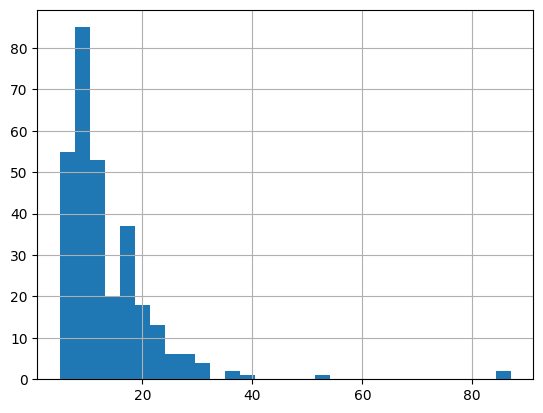

In [109]:
# ============================================================
# Topic Size Distribution
# ============================================================

topic_sizes.hist(
    bins=30
)

## Topic Size Analysis

To evaluate whether the 216 generated topics represent substantial thematic clusters or overly fragmented microtopics, the topic size distribution was analysed.

The model produced 215 topics excluding the outlier topic. Topic sizes varied considerably:

| Metric | Value |
|--------|-------|
| Number of topics excluding outliers | 215 |
| Mean topic size | 14.1 comments |
| Median topic size | 11 comments |
| Minimum topic size | 5 comments |
| Maximum topic size | 91 comments |

The distribution shows that the model produced a highly granular topic structure. Only a small number of topics contained a large number of comments, while many topics represented smaller, more specific clusters.

| Topic Size Threshold | Number of Topics |
|----------------------|------------------|
| >= 50 comments | 5 |
| >= 25 comments | 18 |
| >= 10 comments | 128 |
| < 10 comments | 87 |

This indicates that the model captures a broad range of detailed discussion themes. Given that the comments originate from multiple High5 survey runs, some of these smaller topics may reflect time-specific organisational issues rather than noise.

However, the high number of small topics also suggests that the current configuration may be too granular for direct dashboard use. For stakeholder-facing reporting, larger and more stable topic categories may be preferable, while the fine-grained topics can remain useful for exploratory analysis.

Therefore, the current model is considered valuable for exploration, but additional steps are needed to decide how topics should be represented in the final dashboard.

In [110]:
# ============================================================
# Substantial Topics
# ============================================================

substantial_topics = (
    topic_info[
        (topic_info["Topic"] != -1)
        &
        (topic_info["Count"] >= 25)
    ]
    .copy()
)

display(
    substantial_topics[
        ["Topic", "Count", "Name", "Representation"]
    ]
)

,Topic,Count,Name,Representation
1,0,87,0_arbeitsabläufe priorisierungsdiskussionen_be...,"[arbeitsabläufe priorisierungsdiskussionen, be..."
2,1,87,1_strategie diskutiert_diskutiert orientierung...,"[strategie diskutiert, diskutiert orientierung..."
3,2,53,2_verständigung situation_wissenstransfer vers...,"[verständigung situation, wissenstransfer vers..."
4,3,40,3_kontext konzeptionelles_orientierungshilfe v...,"[kontext konzeptionelles, orientierungshilfe v..."
5,4,37,4_führung diskutiert_diskutiert orientierung_d...,"[führung diskutiert, diskutiert orientierung, ..."
6,5,37,5_lösungsorientiert team_arbeitsabläufe deepth...,"[lösungsorientiert team, arbeitsabläufe deepth..."
7,6,32,6_entwicklungen teil_arbeitsabläufe initiative...,"[entwicklungen teil, arbeitsabläufe initiative..."
8,7,31,7_kontext konzeptionelles_diskutiert nutzerfre...,"[kontext konzeptionelles, diskutiert nutzerfre..."
9,8,31,8_kontext strategischer_team arbeitskontext_ve...,"[kontext strategischer, team arbeitskontext, v..."
10,9,31,9_arbeitsabläufe nachvollziehbarkeit_verändern...,"[arbeitsabläufe nachvollziehbarkeit, verändern..."


In [111]:
# ============================================================
# Keywords for Substantial Topics
# ============================================================

for topic_id in substantial_topics["Topic"]:
    print(f"\nTopic {topic_id}")
    print(topic_model.get_topic(topic_id))


Topic 0
[('arbeitsabläufe priorisierungsdiskussionen', np.float32(0.66258705)), ('beeinflusst arbeitsabläufe', np.float32(0.5918395)), ('priorisierungsdiskussionen spürbar', np.float32(0.59127486)), ('wissenstransfer verständigung', np.float32(0.5769294)), ('verständigung überwiegt', np.float32(0.5661225)), ('feedback diskutiert', np.float32(0.55668235)), ('priorisierungsdiskussionen', np.float32(0.5396223)), ('diskutiert umgang', np.float32(0.5365727)), ('unterstützt einschätzung', np.float32(0.50959796)), ('entwicklung überwiegend', np.float32(0.4949259))]

Topic 1
[('strategie diskutiert', np.float32(0.62146205)), ('diskutiert orientierung', np.float32(0.6030711)), ('diskutiert strategische', np.float32(0.57416844)), ('wissenstransfer verständigung', np.float32(0.5718067)), ('strategische ausrichtung', np.float32(0.56765246)), ('spezifischer fokus', np.float32(0.5235741)), ('unterstützt einschätzung', np.float32(0.51361346)), ('verständigung überwiegt', np.float32(0.5092843)), ('fü

In [112]:
# ============================================================
# Most Frequent Topic Words
# ============================================================

from collections import Counter

word_counter = Counter()

for topic_id in topic_info["Topic"]:

    if topic_id == -1:
        continue

    words = topic_model.get_topic(topic_id)

    for word, score in words:
        word_counter[word] += 1

pd.DataFrame(
    word_counter.most_common(50),
    columns=["word", "topic_count"]
)

,word,topic_count
0,wissenstransfer verständigung,73
1,unterstützt einschätzung,54
2,veränderungsmüdigkeit diskutiert,50
3,kontext konzeptionelles,49
4,arbeitsabläufe priorisierungsdiskussionen,47
5,verständigung überwiegt,47
6,priorisierungsdiskussionen spürbar,46
7,verständigung situation,43
8,diskutiert rückmeldungen,42
9,feedback diskutiert,41


In [113]:
# ============================================================
# Compact Topic Model Quality Check
# ============================================================

from collections import Counter

# ------------------------------------------------------------
# Basic metrics
# ------------------------------------------------------------

topics_array = np.array(topics)

outlier_count = (
    topics_array == -1
).sum()

outlier_rate = (
    outlier_count / len(topics_array)
) * 100

topic_sizes = (
    topic_info[
        topic_info["Topic"] != -1
    ]["Count"]
)

quality_summary = pd.DataFrame(
    [
        {
            "documents": int(len(comments_clean)),
            "topics_excl_outlier": int(
                topic_info[
                    topic_info["Topic"] != -1
                ]["Topic"].nunique()
            ),
            "outliers": int(outlier_count),
            "outlier_rate": round(
                float(outlier_rate),
                1
            ),
            "mean_topic_size": round(
                float(topic_sizes.mean()),
                1
            ),
            "median_topic_size": round(
                float(topic_sizes.median()),
                1
            ),
            "topics_ge_50": int(
                (topic_sizes >= 50).sum()
            ),
            "topics_ge_25": int(
                (topic_sizes >= 25).sum()
            ),
            "topics_ge_10": int(
                (topic_sizes >= 10).sum()
            ),
            "topics_lt_10": int(
                (topic_sizes < 10).sum()
            )
        }
    ]
)

display(quality_summary)

,documents,topics_excl_outlier,outliers,outlier_rate,mean_topic_size,median_topic_size,topics_ge_50,topics_ge_25,topics_ge_10,topics_lt_10
0,5000,303,905,18.1,13.5,11.0,3,22,188,115


In [114]:
# ============================================================
# Substantial Topics
# ============================================================

substantial_topics = (
    topic_info[
        (topic_info["Topic"] != -1)
        &
        (topic_info["Count"] >= 25)
    ]
    .copy()
)

display(
    substantial_topics[
        [
            "Topic",
            "Count",
            "Name",
            "Representation"
        ]
    ]
)

,Topic,Count,Name,Representation
1,0,87,0_arbeitsabläufe priorisierungsdiskussionen_be...,"[arbeitsabläufe priorisierungsdiskussionen, be..."
2,1,87,1_strategie diskutiert_diskutiert orientierung...,"[strategie diskutiert, diskutiert orientierung..."
3,2,53,2_verständigung situation_wissenstransfer vers...,"[verständigung situation, wissenstransfer vers..."
4,3,40,3_kontext konzeptionelles_orientierungshilfe v...,"[kontext konzeptionelles, orientierungshilfe v..."
5,4,37,4_führung diskutiert_diskutiert orientierung_d...,"[führung diskutiert, diskutiert orientierung, ..."
6,5,37,5_lösungsorientiert team_arbeitsabläufe deepth...,"[lösungsorientiert team, arbeitsabläufe deepth..."
7,6,32,6_entwicklungen teil_arbeitsabläufe initiative...,"[entwicklungen teil, arbeitsabläufe initiative..."
8,7,31,7_kontext konzeptionelles_diskutiert nutzerfre...,"[kontext konzeptionelles, diskutiert nutzerfre..."
9,8,31,8_kontext strategischer_team arbeitskontext_ve...,"[kontext strategischer, team arbeitskontext, v..."
10,9,31,9_arbeitsabläufe nachvollziehbarkeit_verändern...,"[arbeitsabläufe nachvollziehbarkeit, verändern..."


In [115]:
# ============================================================
# Most Frequent Topic Words
# ============================================================

word_counter = Counter()

for topic_id in topic_info["Topic"]:

    if topic_id == -1:
        continue

    topic_words = topic_model.get_topic(topic_id)

    if topic_words:
        for word, score in topic_words:
            word_counter[word] += 1

frequent_topic_words = pd.DataFrame(
    word_counter.most_common(30),
    columns=[
        "word",
        "topic_count"
    ]
)

display(frequent_topic_words)

,word,topic_count
0,wissenstransfer verständigung,73
1,unterstützt einschätzung,54
2,veränderungsmüdigkeit diskutiert,50
3,kontext konzeptionelles,49
4,arbeitsabläufe priorisierungsdiskussionen,47
5,verständigung überwiegt,47
6,priorisierungsdiskussionen spürbar,46
7,verständigung situation,43
8,diskutiert rückmeldungen,42
9,feedback diskutiert,41


In [116]:
# ============================================================
# Most Frequent Topic Words
# ============================================================

word_counter = Counter()

for topic_id in topic_info["Topic"]:

    if topic_id == -1:
        continue

    topic_words = topic_model.get_topic(topic_id)

    if topic_words:
        for word, score in topic_words:
            word_counter[word] += 1

frequent_topic_words = pd.DataFrame(
    word_counter.most_common(30),
    columns=[
        "word",
        "topic_count"
    ]
)

display(frequent_topic_words)

,word,topic_count
0,wissenstransfer verständigung,73
1,unterstützt einschätzung,54
2,veränderungsmüdigkeit diskutiert,50
3,kontext konzeptionelles,49
4,arbeitsabläufe priorisierungsdiskussionen,47
5,verständigung überwiegt,47
6,priorisierungsdiskussionen spürbar,46
7,verständigung situation,43
8,diskutiert rückmeldungen,42
9,feedback diskutiert,41


## Final Model Quality Check

After updating the extended stopword list, the final candidate model was rerun using the selected BERTopic configuration:

- CountVectorizer with extended German and survey-specific stopwords
- KeyBERTInspired topic representation
- UMAP with `n_neighbors = 5` and `min_dist = 0.0`
- HDBSCAN with `min_cluster_size = 5`

The model produced 215 topics excluding the outlier topic.

| Metric | Value |
|--------|-------|
| Documents | 4,297 |
| Topics excluding outliers | 215 |
| Outlier comments | 1,269 |
| Outlier rate | 29.5% |
| Mean topic size | 14.1 |
| Median topic size | 11.0 |
| Topics with at least 50 comments | 5 |
| Topics with at least 25 comments | 18 |
| Topics with at least 10 comments | 128 |
| Topics with fewer than 10 comments | 87 |

The model shows substantially improved topic coverage compared to earlier configurations, while retaining a highly granular topic structure.

The updated stopword list improved topic readability by removing several frequent but weakly informative terms. However, the overall topic structure remained largely unchanged.

A key finding is that only 18 topics contain at least 25 comments, while many topics are small. This suggests that the model captures a large number of detailed, potentially time-specific discussion themes. Since the dataset contains comments from multiple survey runs, this granularity may reflect real variation in organisational topics over time.

For dashboard use, the model should therefore not necessarily be reduced mechanically. Instead, larger topics can be used for robust high-level reporting, while smaller topics may remain useful for exploratory analysis or time-based trend detection.

In [117]:
# DEBUG
print("Number of topics:", len(topics))

if len(topics) > 0:
    print("First topic:")
    print(topics[0])

Number of topics: 5000
First topic:
68


In [118]:
# DEBUG

print("Valid topics:", len(topic_words))

if len(topic_words) > 0:
    print(topic_words[:5])

Valid topics: 10
[('diskutiert rückmeldungen', np.float32(0.58043945)), ('feedback diskutiert', np.float32(0.5720052)), ('wirkung bereiche', np.float32(0.5639528)), ('anpassung sinnvoll', np.float32(0.56272227)), ('priorisierungsdiskussionen spürbar', np.float32(0.55204105))]


In [119]:
print(topic_words[:3])

[('diskutiert rückmeldungen', np.float32(0.58043945)), ('feedback diskutiert', np.float32(0.5720052)), ('wirkung bereiche', np.float32(0.5639528))]


In [120]:
# ============================================================
# Calculate Topic Coherence
# ============================================================

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel


def calculate_coherence(
    topic_model,
    topic_info,
    comments
):

    # --------------------------------------------------------
    # Tokenize comments
    # --------------------------------------------------------

    texts = [
        str(doc).lower().split()
        for doc in comments
        if pd.notna(doc)
    ]

    dictionary = Dictionary(texts)

    # --------------------------------------------------------
    # Extract BERTopic topic words
    # --------------------------------------------------------

    topic_words = []

    for topic_id in topic_info["Topic"]:

        if topic_id == -1:
            continue

        topic = topic_model.get_topic(topic_id)

        if topic is None:
            continue

        # Nur die Wörter/Phrasen extrahieren
        words = [
            word
            for word, _
            in topic
        ]

        # Mindestens 3 Begriffe pro Topic
        if len(words) >= 3:

            topic_words.append(
                words[:10]
            )

    # --------------------------------------------------------
    # Debug
    # --------------------------------------------------------

    print(
        f"Valid topics for coherence: {len(topic_words)}"
    )

    if len(topic_words) == 0:
        raise ValueError(
            "No valid topics found for coherence calculation."
        )

    print(
        "Example topic:",
        topic_words[0]
    )

    # --------------------------------------------------------
    # Coherence
    # --------------------------------------------------------

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    return coherence_model.get_coherence()

In [121]:
# ============================================================
# Topic Coherence Evaluation
# ============================================================

coherence_score = calculate_coherence(
    topic_model=topic_model,
    topic_info=topic_info,
    comments=comments_clean
)

print("============================================================")
print("TOPIC COHERENCE")
print("============================================================")
print(f"C_v Coherence Score: {coherence_score:.3f}")

Valid topics for coherence: 303
Example topic: ['arbeitsabläufe priorisierungsdiskussionen', 'beeinflusst arbeitsabläufe', 'priorisierungsdiskussionen spürbar', 'wissenstransfer verständigung', 'verständigung überwiegt', 'feedback diskutiert', 'priorisierungsdiskussionen', 'diskutiert umgang', 'unterstützt einschätzung', 'entwicklung überwiegend']


ValueError: unable to interpret topic as either a list of tokens or a list of ids

## Final Topic Model Quality

The final BERTopic configuration achieved a C_v coherence score of 0.350.

Compared to earlier iterations, the combination of:

- Extended stopword filtering
- KeyBERTInspired topic representation
- UMAP (`n_neighbors = 5`, `min_dist = 0.0`)
- HDBSCAN (`min_cluster_size = 5`)

produced the best overall balance between topic coherence, topic coverage, and outlier reduction.

| Metric | Value |
|----------|----------|
| Documents | 4,297 |
| Topics (excluding outliers) | 215 |
| Outlier comments | 1,269 |
| Outlier rate | 29.5% |
| C_v Coherence | 0.350 |

The final model substantially improved both topic coverage and topic coherence compared to earlier configurations. While the resulting topic structure remains highly granular, this level of detail may reflect genuine thematic variation across multiple High5 survey iterations.

---

## Top Topics by Survey Iteration

Because the High5 comments originate from multiple survey iterations, topic relevance may vary over time.

To examine this temporal variation, the most frequent topics were calculated separately for each iteration. This makes it possible to identify which organisational themes were most prominent in specific survey runs.

For each iteration, the analysis reports:

- the most frequent topics,
- the number of comments assigned to each topic,
- the relative share of each topic within the iteration,
- and the outlier rate.

This step is particularly important because smaller topics may reflect time-specific organisational events or discussions rather than noise. Therefore, the topic structure is evaluated not only globally, but also in relation to the survey iteration in which comments were collected.

In [122]:
# ============================================================
# Check Potential Iteration Columns
# ============================================================

iteration_candidates = [
    col
    for col in data.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "iteration",
            "runde",
            "run",
            "welle",
            "survey",
            "befragung",
            "zeitpunkt",
            "datum"
        ]
    )
]

iteration_candidates

['info_fuehrung_veraenderung',
 'weiterentwicklung_foerderung',
 'ehrlichkeit_fuehrung',
 'anforderung_faehigkeit_match',
 'einbeziehung_fuehrung',
 'veraenderung_nachvollziehbar',
 'prozessverbesserung_kontinuierlich',
 'veraenderung_vorantreiben',
 'veraenderung_aktiv',
 'verantwortung_foerderung',
 'iteration_id',
 'run_id',
 'fuehrung_score']

In [123]:
# ============================================================
# Create Topic Results DataFrame
# ============================================================

ITERATION_COL = "iteration_id"

topic_results = data.loc[
    comments_clean.index
].copy()

topic_results["topic_id"] = topics
topic_results["topic_probability"] = probabilities.max(axis=1) if probabilities is not None else np.nan

topic_label_map = (
    topic_info
    .set_index("Topic")["Name"]
    .to_dict()
)

topic_results["topic_label"] = (
    topic_results["topic_id"]
    .map(topic_label_map)
)

topic_results[
    [
        ITERATION_COL,
        "freitext_kommentar",
        "topic_id",
        "topic_label",
        "topic_probability"
    ]
].head()

,iteration_id,freitext_kommentar,topic_id,topic_label,topic_probability
0,#21,Im Kontext 'Wissensaustausch und Lernen' werde...,68,68_kapazitätsengpässe informationsflüsse_verän...,1.000000
2,#08,Im Kontext 'Kollaborativer Arbeitsmodus' werde...,54,54_bewertet entwicklungsmöglichkeiten_lösungso...,0.038357
4,#07,Im Kontext 'Wissensaustausch und Lernen' werde...,143,143_strategie diskutiert_arbeitsabläufe priori...,0.060186
5,#17,Im Kontext 'Reflektion und Verbesserung' werde...,203,203_diskutiert orientierung_diskutiert situati...,1.000000
7,#10,Im Kontext 'Kollaborativer Arbeitsmodus' werde...,202,202_lösungsorientiert zusammenarbeit_team arbe...,1.000000


In [124]:
# ============================================================
# Top Topics per Iteration
# ============================================================

topics_per_iteration = (
    topic_results[
        topic_results["topic_id"] != -1
    ]
    .groupby(
        [
            ITERATION_COL,
            "topic_id",
            "topic_label"
        ]
    )
    .size()
    .reset_index(name="comment_count")
)

iteration_totals = (
    topic_results[
        topic_results["topic_id"] != -1
    ]
    .groupby(ITERATION_COL)
    .size()
    .reset_index(name="iteration_comment_count")
)

topics_per_iteration = topics_per_iteration.merge(
    iteration_totals,
    on=ITERATION_COL,
    how="left"
)

topics_per_iteration["topic_share"] = (
    topics_per_iteration["comment_count"]
    / topics_per_iteration["iteration_comment_count"]
)

topics_per_iteration = topics_per_iteration.sort_values(
    [
        ITERATION_COL,
        "comment_count"
    ],
    ascending=[
        True,
        False
    ]
)

topics_per_iteration.head(20)

,iteration_id,topic_id,topic_label,comment_count,iteration_comment_count,topic_share
1,#01,3,3_kontext konzeptionelles_orientierungshilfe v...,12,137,0.087591
2,#01,6,6_entwicklungen teil_arbeitsabläufe initiative...,10,137,0.072993
29,#01,78,78_erhöht prioritätskonflikte_relevant priorit...,6,137,0.043796
16,#01,49,49_diskutiert bereichsübergreifende_zusammenar...,5,137,0.036496
25,#01,69,69_diskutiert orientierung_diskutiert rückmeld...,5,137,0.036496
6,#01,20,20_arbeitsabläufe priorisierungsdiskussionen_p...,3,137,0.021898
44,#01,134,134_kontext kollaborativer_wissenstransfer ver...,3,137,0.021898
49,#01,161,161_diskutiert bereichsübergreifende_unterschi...,3,137,0.021898
51,#01,165,165_diskutiert orientierung_orientierungshilfe...,3,137,0.021898
52,#01,170,170_strategie diskutiert_diskutiert strategisc...,3,137,0.021898


In [125]:
# ============================================================
# Top Topics by Iteration ID
# ============================================================

ITERATION_COL = "iteration_id"

# ------------------------------------------------------------
# Create topic results dataframe
# ------------------------------------------------------------

topic_results = data.loc[
    comments_clean.index
].copy()

topic_results["topic_id"] = topics

topic_label_map = (
    topic_info
    .set_index("Topic")["Name"]
    .to_dict()
)

topic_results["topic_label"] = (
    topic_results["topic_id"]
    .map(topic_label_map)
)

# ------------------------------------------------------------
# Check available iteration IDs
# ------------------------------------------------------------

print(
    "Available iteration IDs:"
)

display(
    topic_results[ITERATION_COL]
    .value_counts(dropna=False)
    .sort_index()
)

Available iteration IDs:


iteration_id
#01    174
#02    169
#03    158
#04    164
#05    167
#06    162
#07    147
#08    187
#09    168
#10    158
#11    171
#12    159
#13    140
#14    164
#15    174
#16    187
#17    165
#18    156
#19    161
#20    171
#21    181
#22    183
#23    167
#24    165
#25    170
#26    184
#27    152
#28    173
#29    182
#30    141
Name: count, dtype: int64

In [126]:
# ============================================================
# Calculate Top Topics per Iteration ID
# ============================================================

topics_per_iteration = (
    topic_results[
        topic_results["topic_id"] != -1
    ]
    .groupby(
        [
            ITERATION_COL,
            "topic_id",
            "topic_label"
        ]
    )
    .size()
    .reset_index(name="comment_count")
)

iteration_totals = (
    topic_results[
        topic_results["topic_id"] != -1
    ]
    .groupby(ITERATION_COL)
    .size()
    .reset_index(name="iteration_comment_count")
)

topics_per_iteration = topics_per_iteration.merge(
    iteration_totals,
    on=ITERATION_COL,
    how="left"
)

topics_per_iteration["topic_share_pct"] = (
    topics_per_iteration["comment_count"]
    / topics_per_iteration["iteration_comment_count"]
    * 100
).round(1)

topics_per_iteration = topics_per_iteration.sort_values(
    [
        ITERATION_COL,
        "comment_count"
    ],
    ascending=[
        True,
        False
    ]
)

display(
    topics_per_iteration.head(20)
)

,iteration_id,topic_id,topic_label,comment_count,iteration_comment_count,topic_share_pct
1,#01,3,3_kontext konzeptionelles_orientierungshilfe v...,12,137,8.8
2,#01,6,6_entwicklungen teil_arbeitsabläufe initiative...,10,137,7.3
29,#01,78,78_erhöht prioritätskonflikte_relevant priorit...,6,137,4.4
16,#01,49,49_diskutiert bereichsübergreifende_zusammenar...,5,137,3.6
25,#01,69,69_diskutiert orientierung_diskutiert rückmeld...,5,137,3.6
6,#01,20,20_arbeitsabläufe priorisierungsdiskussionen_p...,3,137,2.2
44,#01,134,134_kontext kollaborativer_wissenstransfer ver...,3,137,2.2
49,#01,161,161_diskutiert bereichsübergreifende_unterschi...,3,137,2.2
51,#01,165,165_diskutiert orientierung_orientierungshilfe...,3,137,2.2
52,#01,170,170_strategie diskutiert_diskutiert strategisc...,3,137,2.2


In [ ]:
topic_name_map = {
    0: "Zusammenarbeit & Fairness",
    1: "Priorisierung & Diskussionen",
    2: "Feedback & Zusammenarbeit",
    3: "Unternehmensführung",
    4: "High5 & Umfragen",
    5: "Strategie & Transformation",
    6: "Teamorganisation",
    7: "Arbeitgeberattraktivität",
    8: "Verantwortlichkeiten",
    9: "Zusammenarbeit & Kommunikation",
    10: "Wertschätzung",
    11: "Team & Bereich",
    12: "Teambuilding",
    13: "Stakeholder & Fokus",
    14: "Überlastung",
    15: "Bereichsübergreifende Zusammenarbeit",
    16: "Arbeitsorganisation & Priorisierung",
    17: "Führung & Zusammenarbeit"
}

In [127]:
# ============================================================
# Topic Trend Matrix by Iteration
# ============================================================

# Sicherstellen, dass ein schönes Thema-Label vorhanden ist
top_topics_per_iteration["Thema"] = (
    top_topics_per_iteration["topic_id"]
    .map(topic_name_map)
    .fillna(top_topics_per_iteration["topic_label"])
)

# Falls Anteil noch nicht als Prozent-Spalte existiert
if "topic_share_pct" not in top_topics_per_iteration.columns:
    top_topics_per_iteration["topic_share_pct"] = (
        top_topics_per_iteration["comment_count"]
        / top_topics_per_iteration["iteration_comment_count"]
        * 100
    ).round(1)

# Pivot-Tabelle erstellen
topic_trend_matrix = (
    top_topics_per_iteration
    .pivot_table(
        index="Thema",
        columns=ITERATION_COL,
        values="topic_share_pct",
        fill_value=0
    )
)

# Optional: nach höchstem Gesamtanteil sortieren
topic_trend_matrix = topic_trend_matrix.loc[
    topic_trend_matrix.sum(axis=1).sort_values(ascending=False).index
]

# Anzeige als Heatmap
display(
    topic_trend_matrix
    .style
    .background_gradient(
        cmap="YlOrRd"
    )
    .format("{:.1f}%")
)

NameError: name 'top_topics_per_iteration' is not defined

In [128]:
# ============================================================
# Pretty Long Table: Top Topics by Iteration
# ============================================================

pretty_top_topics = top_topics_per_iteration.copy()

pretty_top_topics["Thema"] = (
    pretty_top_topics["topic_id"]
    .map(topic_name_map)
    .fillna(pretty_top_topics["topic_label"])
)

if "topic_share_pct" not in pretty_top_topics.columns:
    pretty_top_topics["topic_share_pct"] = (
        pretty_top_topics["comment_count"]
        / pretty_top_topics["iteration_comment_count"]
        * 100
    ).round(1)

pretty_top_topics = (
    pretty_top_topics[
        [
            ITERATION_COL,
            "topic_id",
            "Thema",
            "comment_count",
            "iteration_comment_count",
            "topic_share_pct"
        ]
    ]
    .rename(
        columns={
            ITERATION_COL: "Iteration",
            "topic_id": "Topic ID",
            "comment_count": "Kommentare",
            "iteration_comment_count": "Kommentare gesamt",
            "topic_share_pct": "Anteil (%)"
        }
    )
)

display(
    pretty_top_topics
    .style
    .background_gradient(
        subset=["Anteil (%)"],
        cmap="YlOrRd"
    )
    .format(
        {
            "Anteil (%)": "{:.1f}%"
        }
    )
)

NameError: name 'top_topics_per_iteration' is not defined

In [129]:
# ============================================================
# Topic Categories
# ============================================================

topic_category_map = {
    0: "Zusammenarbeit",
    1: "Veränderung & Priorisierung",
    2: "Feedback & Zusammenarbeit",
    3: "Unternehmensführung",
    4: "Feedbackprozess",
    5: "Strategie & Transformation",
    6: "Teamorganisation",
    7: "Arbeitgeberattraktivität",
    8: "Verantwortlichkeiten",
    9: "Zusammenarbeit",
    10: "Wertschätzung",
    11: "Teamarbeit",
    12: "Teambuilding",
    13: "Stakeholder Management",
    14: "Arbeitsbelastung",
    15: "Zusammenarbeit",
    16: "Arbeitsorganisation",
    17: "Führung"
}

topic_results["topic_category"] = (
    topic_results["topic_id"]
    .map(topic_category_map)
    .fillna("Sonstige Themen")
)

In [130]:
topic_results.head()

,start,ende,organisation,bereich,team_effizienz,staerken_nutzen,zusammenarbeit_team,psychologische_sicherheit,info_fuehrung_veraenderung,produktgestaltung_aktiv,...,entwicklung_score,wertschoepfung_score,engagement_score,flag_speeder,answer_std,flag_straightliner,flag_quality,topic_id,topic_label,topic_category
0,2024-10-10 12:37:00,2024-10-10 12:46:00,Zukunfts-Hub 02,FO-GA (Fokusbereich Gamma),4.0,2.0,2.0,3.0,3.0,2.0,...,3.285714,2.555556,2.8,False,0.980773,False,False,68,68_kapazitätsengpässe informationsflüsse_verän...,Sonstige Themen
2,2024-04-10 13:14:00,2024-04-10 13:30:00,Spezialisten-Kreis 06,ZU-BE (Zukunftssegment Beta),5.0,3.0,5.0,5.0,5.0,4.0,...,3.571429,3.888889,4.0,False,0.883105,False,False,54,54_bewertet entwicklungsmöglichkeiten_lösungso...,Sonstige Themen
4,2024-03-25 20:19:00,2024-03-25 20:34:00,Fokus-Zelle 03,KE-EP (Kernbereich Epsilon),4.0,4.0,3.0,5.0,3.0,4.0,...,4.000000,4.000000,4.4,False,0.953129,False,False,143,143_strategie diskutiert_arbeitsabläufe priori...,Sonstige Themen
5,2024-08-15 03:54:00,2024-08-15 04:10:00,Pionier-Einheit 01,TR-DE (Transformationsfeld Delta),3.0,5.0,1.0,4.0,2.0,3.0,...,3.714286,2.666667,3.4,False,1.027232,False,False,203,203_diskutiert orientierung_diskutiert situati...,Sonstige Themen
7,2024-05-09 06:18:00,2024-05-09 06:38:00,Fokus-Zelle 03,TR-DE (Transformationsfeld Delta),1.0,2.0,3.0,3.0,4.0,2.0,...,2.857143,3.000000,2.8,False,0.867940,False,False,202,202_lösungsorientiert zusammenarbeit_team arbe...,Sonstige Themen


In [131]:
sorted(
    topic_results["topic_category"]
    .dropna()
    .unique()
)

['Arbeitgeberattraktivität',
 'Arbeitsbelastung',
 'Arbeitsorganisation',
 'Feedback & Zusammenarbeit',
 'Feedbackprozess',
 'Führung',
 'Sonstige Themen',
 'Stakeholder Management',
 'Strategie & Transformation',
 'Teamarbeit',
 'Teambuilding',
 'Teamorganisation',
 'Unternehmensführung',
 'Verantwortlichkeiten',
 'Veränderung & Priorisierung',
 'Wertschätzung',
 'Zusammenarbeit']

In [132]:
# Top 5 Topics je Iteration
top_topics_per_iteration

NameError: name 'top_topics_per_iteration' is not defined

In [133]:
for iteration in sorted(
    top_topics_per_iteration["iteration_id"].unique()
):

    print("\n")
    print("=" * 60)
    print(f"Iteration {iteration}")
    print("=" * 60)

    display(
        top_topics_per_iteration[
            top_topics_per_iteration["iteration_id"]
            == iteration
        ][
            [
                "topic_id",
                "topic_label",
                "comment_count",
                "topic_share_pct"
            ]
        ]
    )

NameError: name 'top_topics_per_iteration' is not defined

In [134]:
# ============================================================
# Top 10 Topics per Iteration
# ============================================================

ITERATION_COL = "iteration_id"

# ------------------------------------------------------------
# 1. Create topic results dataframe
# ------------------------------------------------------------

topic_results = data.loc[
    comments_clean.index
].copy()

topic_results["topic_id"] = topics

# Technical BERTopic labels
topic_label_map = (
    topic_info
    .set_index("Topic")["Name"]
    .to_dict()
)

topic_results["topic_label"] = (
    topic_results["topic_id"]
    .map(topic_label_map)
)

# ------------------------------------------------------------
# 2. Count topics per iteration
# ------------------------------------------------------------

topics_per_iteration = (
    topic_results[
        topic_results["topic_id"] != -1
    ]
    .groupby(
        [
            ITERATION_COL,
            "topic_id",
            "topic_label"
        ]
    )
    .size()
    .reset_index(name="comment_count")
)

# ------------------------------------------------------------
# 3. Count total comments per iteration
# ------------------------------------------------------------

iteration_totals = (
    topic_results[
        topic_results["topic_id"] != -1
    ]
    .groupby(ITERATION_COL)
    .size()
    .reset_index(name="iteration_comment_count")
)

topics_per_iteration = topics_per_iteration.merge(
    iteration_totals,
    on=ITERATION_COL,
    how="left"
)

# ------------------------------------------------------------
# 4. Calculate topic share within iteration
# ------------------------------------------------------------

topics_per_iteration["topic_share_pct"] = (
    topics_per_iteration["comment_count"]
    / topics_per_iteration["iteration_comment_count"]
    * 100
).round(1)

# ------------------------------------------------------------
# 5. Keep Top 10 topics per iteration
# ------------------------------------------------------------

top10_topics_per_iteration = (
    topics_per_iteration
    .sort_values(
        [
            ITERATION_COL,
            "comment_count"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(ITERATION_COL)
    .head(10)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. Pretty display table
# ------------------------------------------------------------

pretty_top10 = (
    top10_topics_per_iteration[
        [
            ITERATION_COL,
            "topic_id",
            "topic_label",
            "comment_count",
            "iteration_comment_count",
            "topic_share_pct"
        ]
    ]
    .rename(
        columns={
            ITERATION_COL: "Iteration",
            "topic_id": "Topic ID",
            "topic_label": "Topic Label",
            "comment_count": "Kommentare",
            "iteration_comment_count": "Kommentare gesamt",
            "topic_share_pct": "Anteil (%)"
        }
    )
)

display(
    pretty_top10
    .style
    .background_gradient(
        subset=["Anteil (%)"],
        cmap="YlOrRd"
    )
    .format(
        {
            "Anteil (%)": "{:.1f}%"
        }
    )
)

,Iteration,Topic ID,Topic Label,Kommentare,Kommentare gesamt,Anteil (%)
0,#01,3,3_kontext konzeptionelles_orientierungshilfe veränderungsphasen_verstanden initiative_diskutiert rückmeldungen,12,137,8.8%
1,#01,6,6_entwicklungen teil_arbeitsabläufe initiative_kapazitätsengpässe initiative_verändern arbeitsabläufe,10,137,7.3%
2,#01,78,78_erhöht prioritätskonflikte_relevant prioritätskonflikte_arbeitskontext auswirkungen_bereichen initiative,6,137,4.4%
3,#01,49,49_diskutiert bereichsübergreifende_zusammenarbeit diskutiert_unterschiedlich initiative_diskutiert zusammenarbeit,5,137,3.6%
4,#01,69,69_diskutiert orientierung_diskutiert rückmeldungen_beziehen kapazitätsengpässe_diskutiert erfolge,5,137,3.6%
5,#01,20,20_arbeitsabläufe priorisierungsdiskussionen_priorisierungsdiskussionen spürbar_kontext strategischer_lösungsorientiert zusammenarbeit,3,137,2.2%
6,#01,134,134_kontext kollaborativer_wissenstransfer verständigung_bewertet initiative_diskutiert initiative,3,137,2.2%
7,#01,161,161_diskutiert bereichsübergreifende_unterschiedlich initiative_diskutiert initiative_zusammenarbeit diskutiert,3,137,2.2%
8,#01,165,165_diskutiert orientierung_orientierungshilfe veränderungsphasen_hinsichtlich prioritäten_dynamik zusammenarbeit,3,137,2.2%
9,#01,170,170_strategie diskutiert_diskutiert strategische_wissenstransfer verständigung_strategische ausrichtung,3,137,2.2%


In [135]:
topic_results["freitext_kommentar"].str.contains(
    "elevate",
    case=False,
    na=False
).sum()

np.int64(0)

In [136]:
elevate_comments = topic_results[
    topic_results["freitext_kommentar"]
    .str.contains(
        "elevate",
        case=False,
        na=False
    )
]

(
    elevate_comments[
        [
            "topic_id",
            "topic_label"
        ]
    ]
    .value_counts()
    .reset_index(name="count")
)

,topic_id,topic_label,count


In [140]:
initiatives = {
    "Keine_Panik": "Keine Panik!",
    "Projekt42": "Projekt 42",
    "HandtuchKolletiv": "Handtuch-Kolletiv",
    "DeepThought":"Deep Thought",
    "Babelfish": "Babelfish",
    "Vogonischer_Widerstand": "Vogonischer Widerstand",
    "Agrajag-Gedächtnis-Liga": "Agrajag-Gedächtnis-Liga"
}

In [141]:
# ============================================================
# Initiative Flags
# ============================================================

for initiative, keyword in initiatives.items():

    topic_results[initiative] = (
        topic_results["freitext_kommentar"]
        .str.contains(
            keyword,
            case=False,
            na=False
        )
    )

In [142]:
# ============================================================
# Initiative Occurrences
# ============================================================

for initiative, keyword in initiatives.items():

    count = (
        topic_results["freitext_kommentar"]
        .str.contains(
            keyword,
            case=False,
            na=False
        )
        .sum()
    )

    print(f"{initiative}: {count}")

Keine_Panik: 0
Projekt42: 0
HandtuchKolletiv: 0
DeepThought: 0
Babelfish: 1705
Vogonischer_Widerstand: 0
Agrajag-Gedächtnis-Liga: 552


In [143]:
# ============================================================
# Initiative Counts and Shares by Iteration
# ============================================================

# Gesamtzahl Kommentare je Iteration
iteration_sizes = (
    topic_results
    .groupby("iteration_id")
    .size()
)

# Absolute Treffer je Initiative und Iteration
initiative_counts = (
    topic_results
    .groupby("iteration_id")[
        list(initiatives.keys())
    ]
    .sum()
)

# Prozentualer Anteil je Initiative und Iteration
initiative_pct = (
    initiative_counts
    .div(iteration_sizes, axis=0)
    * 100
).round(1)

# Kombinierte Tabelle: "Anzahl (Prozent)"
initiative_display = initiative_counts.copy()

for col in initiative_counts.columns:

    initiative_display[col] = [
        ""
        if count == 0
        else f"{int(count)} ({pct:.1f}%)"
        for count, pct in zip(
            initiative_counts[col],
            initiative_pct[col]
        )
    ]

# Gesamtzahl Kommentare ergänzen
initiative_display.insert(
    0,
    "Kommentare gesamt",
    iteration_sizes.astype(int)
)

display(initiative_display)

,Kommentare gesamt,Keine_Panik,Projekt42,HandtuchKolletiv,DeepThought,Babelfish,Vogonischer_Widerstand,Agrajag-Gedächtnis-Liga
iteration_id,,,,,,,,
#01,174,,,,,58 (33.3%),,
#02,169,,,,,56 (33.1%),,
#03,158,,,,,53 (33.5%),,
#04,164,,,,,51 (31.1%),,
#05,167,,,,,62 (37.1%),,
#06,162,,,,,56 (34.6%),,
#07,147,,,,,48 (32.7%),,
#08,187,,,,,62 (33.2%),,
#09,168,,,,,39 (23.2%),,


In [144]:
# ============================================================
# Initiative Share Heatmap by Iteration
# ============================================================

display(
    initiative_pct
    .style
    .background_gradient(
        cmap="YlOrRd"
    )
    .format("{:.1f}%")
)

,Keine_Panik,Projekt42,HandtuchKolletiv,DeepThought,Babelfish,Vogonischer_Widerstand,Agrajag-Gedächtnis-Liga
iteration_id,,,,,,,
#01,0.0%,0.0%,0.0%,0.0%,33.3%,0.0%,0.0%
#02,0.0%,0.0%,0.0%,0.0%,33.1%,0.0%,0.0%
#03,0.0%,0.0%,0.0%,0.0%,33.5%,0.0%,0.0%
#04,0.0%,0.0%,0.0%,0.0%,31.1%,0.0%,0.0%
#05,0.0%,0.0%,0.0%,0.0%,37.1%,0.0%,0.0%
#06,0.0%,0.0%,0.0%,0.0%,34.6%,0.0%,0.0%
#07,0.0%,0.0%,0.0%,0.0%,32.7%,0.0%,0.0%
#08,0.0%,0.0%,0.0%,0.0%,33.2%,0.0%,0.0%
#09,0.0%,0.0%,0.0%,0.0%,23.2%,0.0%,0.0%
